EPSG:3857
(58, 20)


<Axes: >

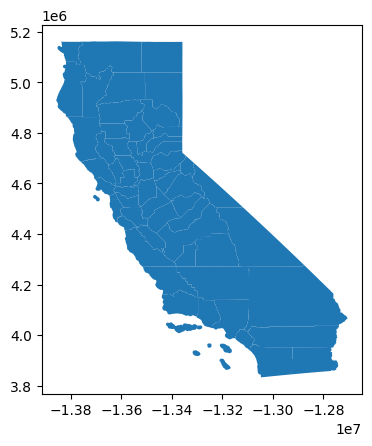

In [1]:
import os
os.environ["KMP_DUPLICATE_LIB_OK"] = "TRUE"

import geopandas as gpd

counties = gpd.read_file("/Users/a.j.sager/Desktop/Climate-Resilience Conservation Project/ca_counties/CA_Counties.shp")

print(counties.crs)
print(counties.shape)
counties.plot()

In [2]:


import os
import pandas as pd
from pygbif import occurrences as occ

data_dir = "/Users/a.j.sager/Desktop/Climate-Resilience Conservation Project/WorldClim Data"

occurrence_cache_path = os.path.join(data_dir, "mountain_lion_occurrences_raw.csv")

if os.path.exists(occurrence_cache_path):
    # Load from cache instead of hitting the API again
    df_raw = pd.read_csv(occurrence_cache_path)
    print(f"Loaded {len(df_raw)} cached records from disk")
else:
    # First time only — pull from GBIF and save
    taxon_key = int(result["usage"]["key"])

    all_records = []
    offset = 0
    limit = 300

    while True:
        resp = occ.search(
            taxonKey=taxon_key,
            country="US",
            stateProvince="California",
            hasCoordinate=True,
            limit=limit,
            offset=offset
        )
        results = resp["results"]
        if not results:
            break
        all_records.extend(results)
        offset += limit
        if resp["endOfRecords"]:
            break

    df_raw = pd.DataFrame(all_records)
    df_raw.to_csv(occurrence_cache_path, index=False)
    print(f"Pulled {len(df_raw)} records from GBIF and cached to disk")

Loaded 4551 cached records from disk


/var/folders/rb/s7j0tw914_s4syhm9zgc7gh40000gn/T/ipykernel_26779/2350495663.py:11: DtypeWarning: Columns (89,103,115,116,117,118,119,120,122,123,124,125,126,127,128,129,130,131,132,135,137,139,140,142,143,144,145,146,148,150,151,152,153,154,155,156,157) have mixed types. Specify dtype option on import or set low_memory=False.
  df_raw = pd.read_csv(occurrence_cache_path)


In [3]:
from pygbif import species

result = species.name_backbone(scientificName="Puma concolor")
print(result["usage"]["key"])

2435099


/var/folders/rb/s7j0tw914_s4syhm9zgc7gh40000gn/T/ipykernel_26779/2113313328.py:30: DeprecationWarning: The 'unary_union' attribute is deprecated, use the 'union_all()' method instead.
  grid = grid[grid.intersects(ca_outline_m.unary_union)].reset_index(drop=True)


(4498, 2)


<Axes: >

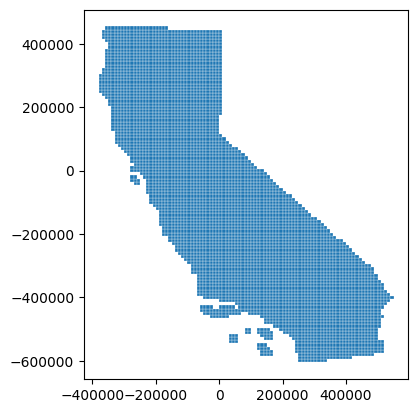

In [4]:
import geopandas as gpd
import numpy as np
from shapely.geometry import box

# Dissolve counties into one CA outline
ca_outline = counties.dissolve()

# Reproject to a metric CRS so "10km" actually means 10km
# CA Albers Equal Area (EPSG:3310) is the standard choice for California analyses
ca_outline_m = ca_outline.to_crs(epsg=3310)

# Get bounding box
minx, miny, maxx, maxy = ca_outline_m.total_bounds

cell_size = 10_000  # 10km in meters

# Build grid cells
grid_cells = []
x = minx
while x < maxx:
    y = miny
    while y < maxy:
        grid_cells.append(box(x, y, x + cell_size, y + cell_size))
        y += cell_size
    x += cell_size

grid = gpd.GeoDataFrame(geometry=grid_cells, crs=ca_outline_m.crs)

# Keep only cells that actually intersect California land
grid = grid[grid.intersects(ca_outline_m.unary_union)].reset_index(drop=True)

# Give each cell a unique ID — you'll use this constantly later to join data
grid["cell_id"] = grid.index

print(grid.shape)  # how many grid cells you ended up with
grid.plot(edgecolor="white", linewidth=0.2)

In [5]:
import pandas as pd
import geopandas as gpd
from shapely.geometry import Point

# Convert to DataFrame
df = df_raw.copy()

# Check what columns actually came back before filtering
print(df.columns.tolist())

['key', 'datasetKey', 'publishingOrgKey', 'installationKey', 'hostingOrganizationKey', 'publishingCountry', 'protocol', 'lastCrawled', 'lastParsed', 'crawlId', 'projectId', 'extensions', 'basisOfRecord', 'occurrenceStatus', 'classifications', 'taxonKey', 'kingdomKey', 'phylumKey', 'classKey', 'orderKey', 'familyKey', 'genusKey', 'speciesKey', 'acceptedTaxonKey', 'scientificName', 'scientificNameAuthorship', 'acceptedScientificName', 'kingdom', 'phylum', 'order', 'family', 'genus', 'species', 'genericName', 'specificEpithet', 'infraspecificEpithet', 'taxonRank', 'taxonomicStatus', 'dateIdentified', 'decimalLatitude', 'decimalLongitude', 'coordinateUncertaintyInMeters', 'continent', 'stateProvince', 'gadm', 'year', 'month', 'day', 'eventDate', 'startDayOfYear', 'endDayOfYear', 'issues', 'modified', 'lastInterpreted', 'references', 'license', 'isSequenced', 'identifiers', 'media', 'facts', 'relations', 'isInCluster', 'datasetName', 'recordedBy', 'identifiedBy', 'dnaSequenceID', 'nucleotid

In [6]:
# Keep only useful columns
df = df[["key", "decimalLatitude", "decimalLongitude", "eventDate",
         "basisOfRecord", "coordinateUncertaintyInMeters", "county"]].copy()

# Check what basisOfRecord values actually exist before filtering
print(df["basisOfRecord"].value_counts())

basisOfRecord
HUMAN_OBSERVATION     4321
PRESERVED_SPECIMEN     220
MATERIAL_CITATION       10
Name: count, dtype: int64


In [7]:
# Keep only direct observations
df = df[df["basisOfRecord"] == "HUMAN_OBSERVATION"].copy()

# Drop missing coordinates
df = df.dropna(subset=["decimalLatitude", "decimalLongitude"])

# Filter out very imprecise coordinates (uncertainty > 5km)
# Keep records where uncertainty is unknown (NaN) OR under 5000m
df = df[(df["coordinateUncertaintyInMeters"].isna()) | (df["coordinateUncertaintyInMeters"] < 5000)]

print(f"Remaining records: {len(df)}")

Remaining records: 2349


In [8]:
from shapely.geometry import Point

# Convert to GeoDataFrame (GBIF coordinates are in WGS84 = EPSG:4326)
geometry = [Point(xy) for xy in zip(df["decimalLongitude"], df["decimalLatitude"])]
occurrences = gpd.GeoDataFrame(df, geometry=geometry, crs="EPSG:4326")

# Reproject to match your grid's CRS (CA Albers, EPSG:3310)
occurrences = occurrences.to_crs(epsg=3310)

# Spatial join: which grid cell does each occurrence fall into?
occurrences_with_cell = gpd.sjoin(
    occurrences,
    grid[["cell_id", "geometry"]],
    how="left",
    predicate="within"
)

print(occurrences_with_cell.shape)
print("Occurrences outside the grid:", occurrences_with_cell["cell_id"].isna().sum())

(2349, 10)
Occurrences outside the grid: 0


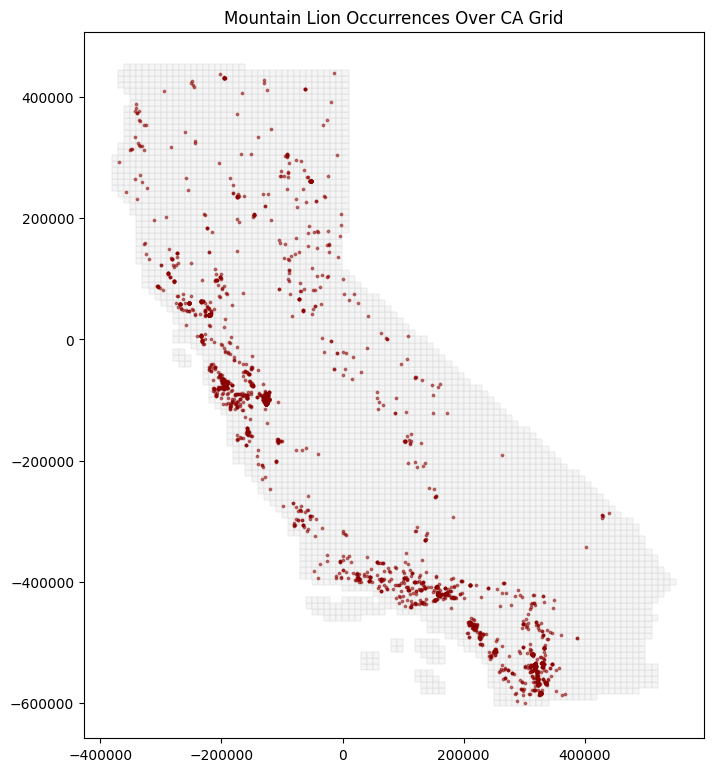

In [9]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(8, 10))
grid.plot(ax=ax, color="whitesmoke", edgecolor="lightgray", linewidth=0.3)
occurrences_with_cell.plot(ax=ax, color="darkred", markersize=3, alpha=0.5)
plt.title("Mountain Lion Occurrences Over CA Grid")
plt.show()

In [10]:
occurrence_counts = (
    occurrences_with_cell.groupby("cell_id")
    .size()
    .reset_index(name="occurrence_count")
)

# Merge counts back onto the full grid (cells with no occurrences get 0)
grid = grid.merge(occurrence_counts, on="cell_id", how="left")
grid["occurrence_count"] = grid["occurrence_count"].fillna(0).astype(int)

print(grid["occurrence_count"].describe())
print("Cells with at least 1 occurrence:", (grid["occurrence_count"] > 0).sum(), "out of", len(grid))

count    4498.000000
mean        0.522232
std         4.019363
min         0.000000
25%         0.000000
50%         0.000000
75%         0.000000
max       133.000000
Name: occurrence_count, dtype: float64
Cells with at least 1 occurrence: 555 out of 4498


In [11]:
import os
import rasterio

data_dir = "/Users/a.j.sager/Desktop/Climate-Resilience Conservation Project/WorldClim Data"

files = [
    "wc2.1_2.5m_bio_1.tif",
    "wc2.1_2.5m_bio_4.tif",
    "wc2.1_2.5m_bio_12.tif",
    "wc2.1_2.5m_elev.tif"
]

for f in files:
    path = os.path.join(data_dir, f)
    with rasterio.open(path) as src:
        print(f, "| CRS:", src.crs, "| shape:", src.shape, "| bounds:", src.bounds)

wc2.1_2.5m_bio_1.tif | CRS: EPSG:4326 | shape: (4320, 8640) | bounds: BoundingBox(left=-180.0, bottom=-90.0, right=180.0, top=90.0)
wc2.1_2.5m_bio_4.tif | CRS: EPSG:4326 | shape: (4320, 8640) | bounds: BoundingBox(left=-180.0, bottom=-90.0, right=180.0, top=90.0)
wc2.1_2.5m_bio_12.tif | CRS: EPSG:4326 | shape: (4320, 8640) | bounds: BoundingBox(left=-180.0, bottom=-90.0, right=180.0, top=90.0)
wc2.1_2.5m_elev.tif | CRS: EPSG:4326 | shape: (4320, 8640) | bounds: BoundingBox(left=-180.0, bottom=-90.0, right=180.0, top=90.0)


In [12]:
# Clip rasters to California (safe to re-run — just overwrites)
import rasterio
from rasterio.mask import mask

ca_outline_wgs84 = ca_outline.to_crs(epsg=4326)
ca_geom = [ca_outline_wgs84.geometry.iloc[0]]

for f in files:
    input_path = os.path.join(data_dir, f)
    output_path = os.path.join(data_dir, "ca_" + f)

    with rasterio.open(input_path) as src:
        out_image, out_transform = mask(src, ca_geom, crop=True)
        out_meta = src.meta.copy()
        out_meta.update({
            "height": out_image.shape[1],
            "width": out_image.shape[2],
            "transform": out_transform
        })

    with rasterio.open(output_path, "w", **out_meta) as dest:
        dest.write(out_image)

    print(f"Clipped: {output_path}")

Clipped: /Users/a.j.sager/Desktop/Climate-Resilience Conservation Project/WorldClim Data/ca_wc2.1_2.5m_bio_1.tif
Clipped: /Users/a.j.sager/Desktop/Climate-Resilience Conservation Project/WorldClim Data/ca_wc2.1_2.5m_bio_4.tif
Clipped: /Users/a.j.sager/Desktop/Climate-Resilience Conservation Project/WorldClim Data/ca_wc2.1_2.5m_bio_12.tif
Clipped: /Users/a.j.sager/Desktop/Climate-Resilience Conservation Project/WorldClim Data/ca_wc2.1_2.5m_elev.tif


In [13]:
import fiona

gdb_path = "/Users/a.j.sager/Desktop/Climate-Resilience Conservation Project/Fire Data.gdb"

layers = fiona.listlayers(gdb_path)
print(layers)

['firep25_1', 'rxburn25_1']


/Users/a.j.sager/anaconda3/lib/python3.11/site-packages/pyogrio/raw.py:200: RuntimeWarning: organizePolygons() received a polygon with more than 100 parts. The processing may be really slow.  You can skip the processing by setting METHOD=SKIP, or only make it analyze counter-clock wise parts by setting METHOD=ONLY_CCW if you can assume that the outline of holes is counter-clock wise defined
  return ogr_read(


EPSG:3310
(23334, 21)
['YEAR_', 'STATE', 'AGENCY', 'UNIT_ID', 'FIRE_NAME', 'INC_NUM', 'IRWINID', 'ALARM_DATE', 'CONT_DATE', 'C_METHOD', 'CAUSE', 'OBJECTIVE', 'GIS_ACRES', 'COMPLEX_ID', 'COMPLEX_NAME', 'COMMENTS', 'FIRE_NUM', 'Shape_Length', 'Shape_Area', 'GlobalID', 'geometry']


<Axes: >

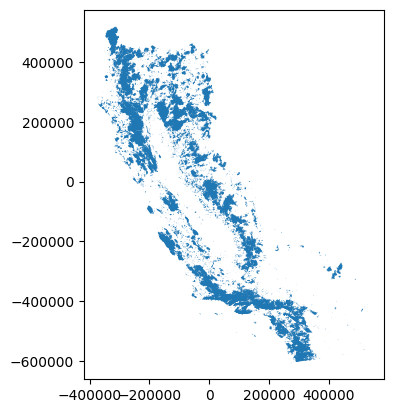

In [14]:
import geopandas as gpd

fire_perimeters = gpd.read_file(gdb_path, layer="firep25_1")

print(fire_perimeters.crs)
print(fire_perimeters.shape)
print(fire_perimeters.columns.tolist())
fire_perimeters.plot()

In [15]:
print(fire_perimeters["YEAR_"].describe())
print(fire_perimeters["YEAR_"].value_counts().sort_index().tail(20))

count    23257.000000
mean      1979.889625
std         34.257083
min       1878.000000
25%       1953.000000
50%       1986.000000
75%       2010.000000
max       2025.000000
Name: YEAR_, dtype: float64
YEAR_
2006.0    314
2007.0    348
2008.0    439
2009.0    254
2010.0    207
2011.0    317
2012.0    351
2013.0    296
2014.0    236
2015.0    314
2016.0    363
2017.0    611
2018.0    416
2019.0    318
2020.0    504
2021.0    388
2022.0    307
2023.0    285
2024.0    553
2025.0    521
Name: count, dtype: int64


In [16]:
# Keep fires from 2000 onward
fire_recent = fire_perimeters[fire_perimeters["YEAR_"] >= 2000].copy()

print(f"Fires from 2000-present: {len(fire_recent)}")
print(fire_recent["GIS_ACRES"].describe())

Fires from 2000-present: 8892
count    8.892000e+03
mean     2.509760e+03
std      2.237570e+04
min      8.994204e-04
25%      1.230884e+01
50%      4.333520e+01
75%      2.434988e+02
max      1.032700e+06
Name: GIS_ACRES, dtype: float64


In [17]:
import numpy as np

# Reproject grid to match fire data CRS (already EPSG:3310, so this should be a no-op, but safe to confirm)
grid_3310 = grid.to_crs(epsg=3310)

# Spatial join: which grid cells does each fire perimeter intersect?
# A single fire can touch multiple cells, and a cell can be touched by multiple fires
fire_grid_join = gpd.sjoin(
    grid_3310[["cell_id", "geometry"]],
    fire_recent[["YEAR_", "GIS_ACRES", "geometry"]],
    how="left",
    predicate="intersects"
)

print(fire_grid_join.shape)
print("Cells with at least one fire:", fire_grid_join.loc[fire_grid_join["YEAR_"].notna(), "cell_id"].nunique())

(14985, 5)
Cells with at least one fire: 2762


In [18]:
# Fire frequency: count of distinct fires touching each cell
fire_frequency = (
    fire_grid_join[fire_grid_join["YEAR_"].notna()]
    .groupby("cell_id")
    .size()
    .reset_index(name="fire_frequency")
)

# Total burned acreage per cell (summed across all fires that touched it)
fire_acreage = (
    fire_grid_join[fire_grid_join["YEAR_"].notna()]
    .groupby("cell_id")["GIS_ACRES"]
    .sum()
    .reset_index(name="total_burned_acres")
)

# Merge both onto the grid
grid = grid.merge(fire_frequency, on="cell_id", how="left")
grid = grid.merge(fire_acreage, on="cell_id", how="left")

# Cells with no fires get 0
grid["fire_frequency"] = grid["fire_frequency"].fillna(0).astype(int)
grid["total_burned_acres"] = grid["total_burned_acres"].fillna(0)

# Log-transform acreage to dampen the influence of megafires
# log1p handles the zeros cleanly (log(1+0) = 0, no -infinity issue)
grid["log_burned_acres"] = np.log1p(grid["total_burned_acres"])

print(grid[["fire_frequency", "total_burned_acres", "log_burned_acres"]].describe())

       fire_frequency  total_burned_acres  log_burned_acres
count     4498.000000        4.498000e+03       4498.000000
mean         2.945531        8.732486e+04          5.619772
std          4.216765        2.170615e+05          5.161926
min          0.000000        0.000000e+00          0.000000
25%          0.000000        0.000000e+00          0.000000
50%          1.000000        3.200542e+02          5.771599
75%          4.000000        4.893343e+04         10.798237
max         43.000000        1.545913e+06         14.251125


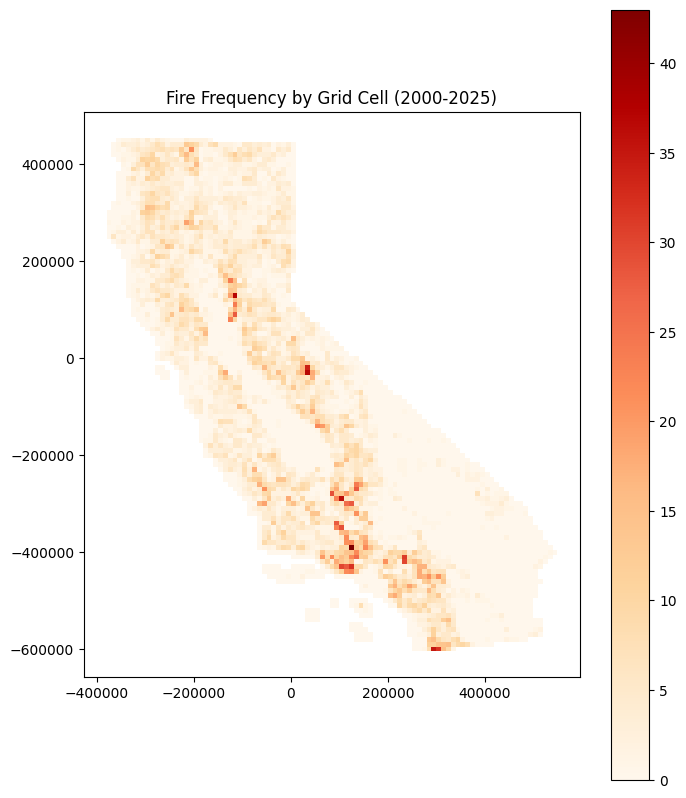

In [19]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(8, 10))
grid.plot(column="fire_frequency", cmap="OrRd", legend=True, ax=ax, edgecolor="none")
plt.title("Fire Frequency by Grid Cell (2000-2025)")
plt.show()

EPSG:3310
(162773, 36)
['HOLDING_ID', 'ACCESS_TYP', 'UNIT_ID', 'UNIT_NAME', 'SUID_NMA', 'AGNCY_ID', 'AGNCY_NAME', 'AGNCY_LEV', 'AGNCY_TYP', 'AGNCY_WEB', 'LAYER', 'MNG_AG_ID', 'MNG_AGNCY', 'MNG_AG_LEV', 'MNG_AG_TYP', 'SITE_NAME', 'ALT_SITE_N', 'PARK_URL', 'LAND_WATER', 'SPEC_USE', 'CITY', 'COUNTY', 'ACRES', 'LABEL_NAME', 'DATE_REVIS', 'SRC_ATTR', 'SRC_ALIGN', 'YR_PROTECT', 'YR_EST', 'GAP1_acres', 'GAP2_acres', 'GAP3_acres', 'GAP4_acres', 'GAP_tot_ac', 'GAP_Source', 'geometry']


<Axes: >

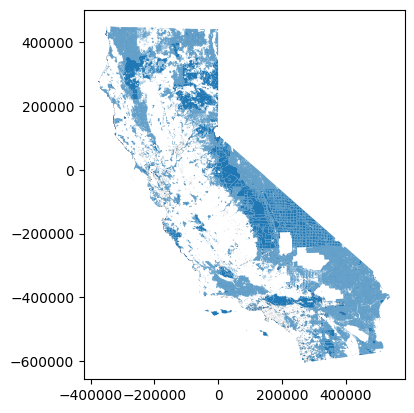

In [20]:
protected_areas = gpd.read_file("/Users/a.j.sager/Desktop/Climate-Resilience Conservation Project/CPAD Data/CPAD_2026a_Holdings.shp")

print(protected_areas.crs)
print(protected_areas.shape)
print(protected_areas.columns.tolist())
protected_areas.plot()

In [21]:
print(protected_areas["LAND_WATER"].value_counts())
print(protected_areas["ACCESS_TYP"].value_counts())

LAND_WATER
Land     160473
Water      2300
Name: count, dtype: int64
ACCESS_TYP
Open Access          145815
Restricted Access      8394
No Public Access       8073
Unknown Access          491
Name: count, dtype: int64


In [22]:
# Keep only land parcels
protected_land = protected_areas[protected_areas["LAND_WATER"] == "Land"].copy()

# Fix any invalid geometries before the overlay (common with large real-world datasets)
protected_land["geometry"] = protected_land["geometry"].buffer(0)

# Dissolve overlapping parcels into one unified shape (avoids double-counting overlaps)
protected_dissolved = protected_land.dissolve()

# Make sure grid is in the same CRS
grid_3310 = grid.to_crs(epsg=3310)
grid_3310["cell_area_m2"] = grid_3310.geometry.area

# Compute actual overlapping area between each grid cell and protected land
intersection = gpd.overlay(
    grid_3310[["cell_id", "geometry"]],
    protected_dissolved[["geometry"]],
    how="intersection"
)
intersection["protected_area_m2"] = intersection.geometry.area

protected_by_cell = intersection.groupby("cell_id")["protected_area_m2"].sum().reset_index()

# Merge back onto grid
grid = grid.merge(protected_by_cell, on="cell_id", how="left")
grid["protected_area_m2"] = grid["protected_area_m2"].fillna(0)
grid = grid.merge(grid_3310[["cell_id", "cell_area_m2"]], on="cell_id", how="left")
grid["pct_protected"] = grid["protected_area_m2"] / grid["cell_area_m2"]

print(grid["pct_protected"].describe())

count    4498.000000
mean        0.445632
std         0.395818
min         0.000000
25%         0.033331
50%         0.359519
75%         0.895119
max         1.000000
Name: pct_protected, dtype: float64


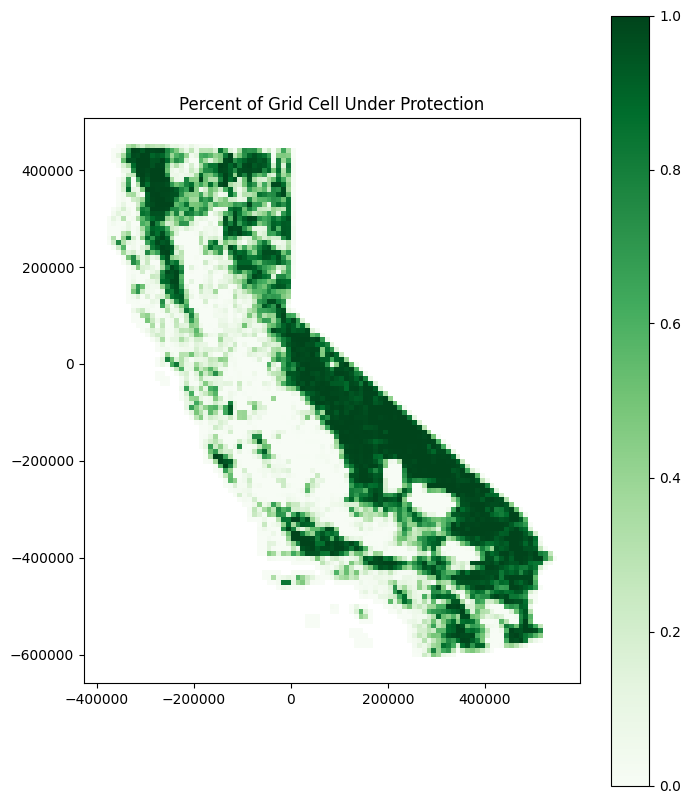

In [23]:
fig, ax = plt.subplots(figsize=(8, 10))
grid.plot(column="pct_protected", cmap="Greens", legend=True, ax=ax, edgecolor="none")
plt.title("Percent of Grid Cell Under Protection")
plt.show()

In [24]:
import rasterio
import numpy as np

# Get centroid coordinates for every grid cell, in the raster's CRS (EPSG:4326)
grid_wgs84 = grid.to_crs(epsg=4326)
centroids = grid_wgs84.geometry.centroid
coords = [(pt.x, pt.y) for pt in centroids]

raster_files = {
    "mean_temp": "ca_wc2.1_2.5m_bio_1.tif",
    "temp_seasonality": "ca_wc2.1_2.5m_bio_4.tif",
    "annual_precip": "ca_wc2.1_2.5m_bio_12.tif",
    "elevation": "ca_wc2.1_2.5m_elev.tif",
}

for col_name, filename in raster_files.items():
    raster_path = os.path.join(data_dir, filename)
    with rasterio.open(raster_path) as src:
        values = [v[0] for v in src.sample(coords)]
    grid[col_name] = values
    print(f"{col_name} done — sample values:", grid[col_name].head(3).tolist())

/var/folders/rb/s7j0tw914_s4syhm9zgc7gh40000gn/T/ipykernel_26779/4047302479.py:6: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  centroids = grid_wgs84.geometry.centroid


mean_temp done — sample values: [-3.3999999521443642e+38, -3.3999999521443642e+38, -3.3999999521443642e+38]
temp_seasonality done — sample values: [-3.3999999521443642e+38, -3.3999999521443642e+38, -3.3999999521443642e+38]
annual_precip done — sample values: [-3.3999999521443642e+38, -3.3999999521443642e+38, -3.3999999521443642e+38]
elevation done — sample values: [-32768, -32768, -32768]


In [25]:
nodata_check = grid[["mean_temp", "elevation"]].copy()
print("Cells with nodata temp:", (nodata_check["mean_temp"] < -1000).sum(), "out of", len(grid))
print("Cells with nodata elevation:", (nodata_check["elevation"] < -1000).sum(), "out of", len(grid))

Cells with nodata temp: 361 out of 4498
Cells with nodata elevation: 361 out of 4498


In [26]:
import numpy as np

for col in ["mean_temp", "temp_seasonality", "annual_precip", "elevation"]:
    grid[col] = grid[col].replace([-3.3999999521443642e+38, -32768], np.nan)

print(grid[["mean_temp", "temp_seasonality", "annual_precip", "elevation"]].isna().sum())

mean_temp           361
temp_seasonality    361
annual_precip       361
elevation           361
dtype: int64


In [27]:
!pip install scipy

In [28]:
import rasterio
import numpy as np

grid_wgs84 = grid.to_crs(epsg=4326)
centroids = grid_wgs84.geometry.centroid
coords = [(pt.x, pt.y) for pt in centroids]

raster_files = {
    "mean_temp": "ca_wc2.1_2.5m_bio_1.tif",
    "temp_seasonality": "ca_wc2.1_2.5m_bio_4.tif",
    "annual_precip": "ca_wc2.1_2.5m_bio_12.tif",
    "elevation": "ca_wc2.1_2.5m_elev.tif",
}

for col_name, filename in raster_files.items():
    raster_path = os.path.join(data_dir, filename)
    with rasterio.open(raster_path) as src:
        values = [v[0] for v in src.sample(coords)]
    grid[col_name] = values

# Replace sentinel nodata values with NaN
for col in raster_files.keys():
    grid[col] = grid[col].replace([-3.3999999521443642e+38, -32768], np.nan)

print(grid[list(raster_files.keys())].isna().sum())

/var/folders/rb/s7j0tw914_s4syhm9zgc7gh40000gn/T/ipykernel_26779/1002495789.py:5: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  centroids = grid_wgs84.geometry.centroid


mean_temp           361
temp_seasonality    361
annual_precip       361
elevation           361
dtype: int64


In [29]:
from scipy.spatial import cKDTree

# Get x, y coordinates for all cell centroids (projected CRS for accurate distance)
grid_3310 = grid.to_crs(epsg=3310)
xy = np.array([(pt.x, pt.y) for pt in grid_3310.geometry.centroid])

for col in raster_files.keys():
    valid_mask = grid[col].notna()
    missing_mask = grid[col].isna()

    if missing_mask.sum() == 0:
        continue

    # Build a tree of cells WITH valid data
    tree = cKDTree(xy[valid_mask])

    # For each missing cell, find its nearest valid neighbor
    _, nearest_idx = tree.query(xy[missing_mask])

    valid_values = grid.loc[valid_mask, col].values
    grid.loc[missing_mask, col] = valid_values[nearest_idx]

print(grid[list(raster_files.keys())].isna().sum())  # should all be 0 now

mean_temp           0
temp_seasonality    0
annual_precip       0
elevation           0
dtype: int64


In [30]:
print(grid[["mean_temp", "temp_seasonality", "annual_precip", "elevation"]].describe())

         mean_temp  temp_seasonality  annual_precip    elevation
count  4498.000000       4498.000000    4498.000000  4498.000000
mean     14.104119        630.404236     552.451538   819.729213
std       4.857088        167.807571     426.610596   732.755528
min      -1.536667        141.217438      55.000000   -81.000000
25%      10.976333        555.353363     213.000000   197.000000
50%      14.836729        662.273682     430.000000   640.500000
75%      17.067584        744.461670     767.000000  1280.750000
max      24.219833        978.287476    2103.000000  3732.000000


In [31]:
grid["mean_temp_c"] = grid["mean_temp"] / 10

In [32]:
from sklearn.preprocessing import MinMaxScaler

# Columns to normalize
cols_to_scale = [
    "occurrence_count", "fire_frequency", "log_burned_acres",
    "pct_protected", "mean_temp", "temp_seasonality", "annual_precip", "elevation"
]

scaler = MinMaxScaler()
scaled_values = scaler.fit_transform(grid[cols_to_scale])

# Add scaled columns with a "_scaled" suffix, keep originals intact
scaled_df = pd.DataFrame(scaled_values, columns=[f"{c}_scaled" for c in cols_to_scale], index=grid.index)
grid = pd.concat([grid, scaled_df], axis=1)

print(grid[[f"{c}_scaled" for c in cols_to_scale]].describe())

       occurrence_count_scaled  fire_frequency_scaled  \
count              4498.000000            4498.000000   
mean                  0.003927               0.068501   
std                   0.030221               0.098064   
min                   0.000000               0.000000   
25%                   0.000000               0.000000   
50%                   0.000000               0.023256   
75%                   0.000000               0.093023   
max                   1.000000               1.000000   

       log_burned_acres_scaled  pct_protected_scaled  mean_temp_scaled  \
count              4498.000000           4498.000000       4498.000000   
mean                  0.394339              0.445632          0.607256   
std                   0.362218              0.395818          0.188577   
min                   0.000000              0.000000          0.000000   
25%                   0.000000              0.033331          0.485819   
50%                   0.404993            

In [33]:
grid["log_occurrence_count"] = np.log1p(grid["occurrence_count"])

# Re-scale just this one column
scaler_occ = MinMaxScaler()
grid["log_occurrence_count_scaled"] = scaler_occ.fit_transform(grid[["log_occurrence_count"]])

print(grid["log_occurrence_count_scaled"].describe())

count    4498.000000
mean        0.030157
std         0.096007
min         0.000000
25%         0.000000
50%         0.000000
75%         0.000000
max         1.000000
Name: log_occurrence_count_scaled, dtype: float64


In [35]:
grid["priority_score"] = (
    0.35 * grid["log_occurrence_count_scaled"]        # habitat suitability / species presence
    - 0.25 * grid["fire_frequency_scaled"]              # wildfire risk (penalize)
    - 0.20 * grid["pct_protected_scaled"]               # already-protected areas score lower (new land is the priority)
    + 0.20 * (1 - grid["temp_seasonality_scaled"])      # climate stability (invert seasonality)
)

print(grid["priority_score"].describe())

count    4498.000000
mean       -0.012577
std         0.109677
min        -0.339843
25%        -0.115500
50%        -0.005456
75%         0.066617
max         0.369088
Name: priority_score, dtype: float64


In [36]:
scaler_final = MinMaxScaler(feature_range=(0, 100))
grid["priority_score_100"] = scaler_final.fit_transform(grid[["priority_score"]])

print(grid["priority_score_100"].describe())

count    4498.000000
mean       46.163226
std        15.470779
min         0.000000
25%        31.645263
50%        47.167729
75%        57.334175
max       100.000000
Name: priority_score_100, dtype: float64


In [37]:
# Top 10 priority cells
top10 = grid.sort_values("priority_score_100", ascending=False).head(10)
print(top10[["cell_id", "priority_score_100", "occurrence_count", "fire_frequency", "pct_protected", "mean_temp"]])

      cell_id  priority_score_100  occurrence_count  fire_frequency  \
1170     1170          100.000000                89               3   
396       396           99.519301                26               1   
542       542           97.105260                47               4   
598       598           95.703295                29               1   
702       702           95.227485                49               0   
643       643           93.423178                14               1   
486       486           92.319262                19               2   
174       174           91.840496                 6               0   
827       827           90.851350                 9               0   
3043     3043           89.735600                44               6   

      pct_protected  mean_temp  
1170       0.239963  14.980000  
396        0.005062  13.718667  
542        0.128588  13.866667  
598        0.091542  14.287000  
702        0.425746  13.961833  
643        0.158753 

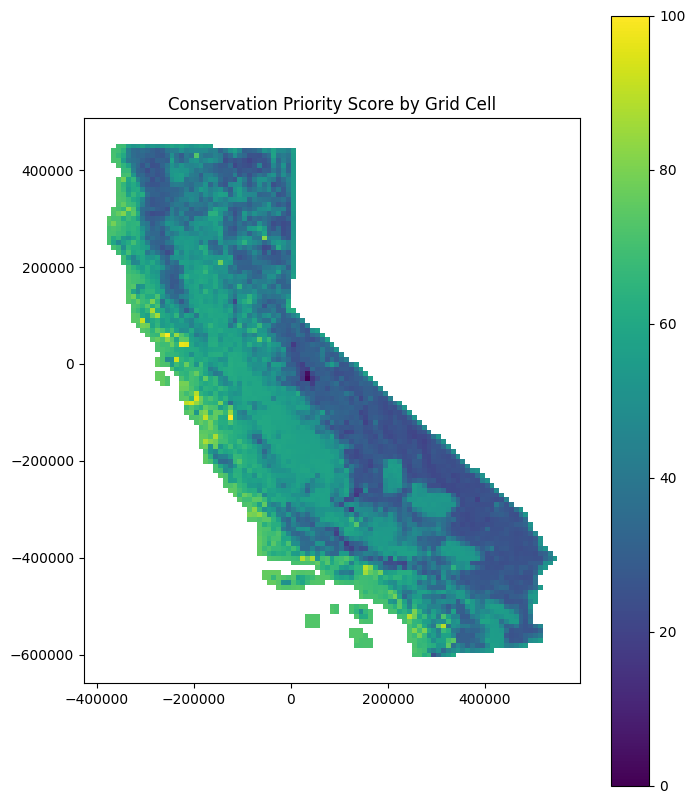

In [38]:
fig, ax = plt.subplots(figsize=(8, 10))
grid.plot(column="priority_score_100", cmap="viridis", legend=True, ax=ax, edgecolor="none")
plt.title("Conservation Priority Score by Grid Cell")
plt.show()

In [39]:
outlier = grid.sort_values("priority_score_100").head(3)
print(outlier[["cell_id", "priority_score_100", "occurrence_count", "fire_frequency", "pct_protected", "mean_temp"]])

      cell_id  priority_score_100  occurrence_count  fire_frequency  \
2449     2449            0.000000                 0              37   
2450     2450            3.481075                 0              34   
2946     2946           15.437920                 0              28   

      pct_protected  mean_temp  
2449       0.996055   8.682667  
2450       0.999236   5.352833  
2946       0.695066  14.458000  


In [40]:
# Convert cell area to acres
grid["cell_area_acres"] = grid["cell_area_m2"] * 0.000247105

# Only unprotected land needs "acquiring" - already-protected land costs nothing further
grid["unprotected_acres"] = grid["cell_area_acres"] * (1 - grid["pct_protected"])

# Assumed cost per acre for conservation acquisition/easement (a simplifying assumption - state this explicitly in the write-up)
COST_PER_ACRE = 2000

grid["estimated_cost"] = grid["unprotected_acres"] * COST_PER_ACRE

print(grid["estimated_cost"].describe())

count    4.498000e+03
mean     2.739741e+07
std      1.956173e+07
min      0.000000e+00
25%      5.183320e+06
50%      3.165322e+07
75%      4.777375e+07
max      4.942100e+07
Name: estimated_cost, dtype: float64


In [41]:
print("Total cost to protect all unprotected land in CA:", grid["estimated_cost"].sum())
print("Number of cells with zero cost (already fully protected):", (grid["estimated_cost"] == 0).sum())

Total cost to protect all unprotected land in CA: 123233553416.8753
Number of cells with zero cost (already fully protected): 28


In [43]:
total_cost = 123233553416.8753
BUDGET = total_cost * 0.02  # 2% of total statewide need

print(f"Total estimated cost: ${total_cost:,.0f}")
print(f"Budget (2% of total): ${BUDGET:,.0f}")
print(f"Roughly {BUDGET / grid['estimated_cost'].median():.0f} median-cost cells affordable")

Total estimated cost: $123,233,553,417
Budget (2% of total): $2,464,671,068
Roughly 78 median-cost cells affordable


In [44]:
!pip install pulp

  Obtaining dependency information for pulp from https://files.pythonhosted.org/packages/dd/6e/d674f1dde91c71e2ac19e5e5cf1ee6d5845e3aefecd9c39ed9c4b0c9a696/pulp-3.3.2-py3-none-any.whl.metadata
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 16.4/16.4 MB 38.5 MB/s eta 0:00:00m eta 0:00:010:01:01


In [45]:
import pulp

# Set up the optimization problem
prob = pulp.LpProblem("Conservation_Budget_Allocation", pulp.LpMaximize)

# Decision variable: binary choice (1 = select this cell, 0 = don't) for every cell
cell_ids = grid["cell_id"].tolist()
select = pulp.LpVariable.dicts("select", cell_ids, cat="Binary")

# Objective: maximize total priority score of selected cells
priority_dict = grid.set_index("cell_id")["priority_score_100"].to_dict()
prob += pulp.lpSum([select[i] * priority_dict[i] for i in cell_ids])

# Constraint: total cost of selected cells must not exceed budget
cost_dict = grid.set_index("cell_id")["estimated_cost"].to_dict()
prob += pulp.lpSum([select[i] * cost_dict[i] for i in cell_ids]) <= BUDGET

# Solve
prob.solve()

print("Status:", pulp.LpStatus[prob.status])

Welcome to the CBC MILP Solver 
Version: 2.10.3 
Build Date: Dec 15 2019 

command line - /Users/a.j.sager/anaconda3/lib/python3.11/site-packages/pulp/apis/../solverdir/cbc/osx/i64/cbc /var/folders/rb/s7j0tw914_s4syhm9zgc7gh40000gn/T/4b506d67f1b44d7bad47cb0808db742e-pulp.mps -max -timeMode elapsed -solve -printingOptions all -solution /var/folders/rb/s7j0tw914_s4syhm9zgc7gh40000gn/T/4b506d67f1b44d7bad47cb0808db742e-pulp.sol (default strategy 1)
At line 2 NAME          MODEL
At line 3 ROWS
At line 6 COLUMNS
At line 17970 RHS
At line 17972 BOUNDS
At line 22471 ENDATA
Problem MODEL has 1 rows, 4498 columns and 4470 elements
Coin0008I MODEL read with 0 errors
Option for timeMode changed from cpu to elapsed
Continuous objective value is 36759.5 - 0.00 seconds
Cgl0004I processed model has 1 rows, 4447 columns (4447 integer (4430 of which binary)) and 4447 elements
Cbc0038I Initial state - 1 integers unsatisfied sum - 0.345854
Cbc0038I Solution found of -36750.3
Cbc0038I Cleaned solution of -

In [46]:
# Extract which cells were selected
selected_cells = [i for i in cell_ids if select[i].varValue == 1]

optimized_selection = grid[grid["cell_id"].isin(selected_cells)].copy()

print(f"Cells selected: {len(optimized_selection)}")
print(f"Total cost: ${optimized_selection['estimated_cost'].sum():,.0f}")
print(f"Total priority score: {optimized_selection['priority_score_100'].sum():,.0f}")
print(f"Average priority score of selected cells: {optimized_selection['priority_score_100'].mean():.1f}")

Cells selected: 1254
Total cost: $2,464,605,098
Total priority score: 36,759
Average priority score of selected cells: 29.3


In [47]:
# Naive approach: rank by priority, buy top cells until budget exhausted
grid_sorted = grid.sort_values("priority_score_100", ascending=False).copy()
grid_sorted["cumulative_cost"] = grid_sorted["estimated_cost"].cumsum()

naive_selection = grid_sorted[grid_sorted["cumulative_cost"] <= BUDGET]

print(f"Naive cells selected: {len(naive_selection)}")
print(f"Naive total cost: ${naive_selection['estimated_cost'].sum():,.0f}")
print(f"Naive total priority score: {naive_selection['priority_score_100'].sum():,.0f}")
print(f"Naive average priority score: {naive_selection['priority_score_100'].mean():.1f}")

Naive cells selected: 59
Naive total cost: $2,452,070,878
Naive total priority score: 4,959
Naive average priority score: 84.1


In [48]:
FIXED_COST_PER_ACQUISITION = 100_000  # administrative/legal/survey overhead per parcel, regardless of size

grid["estimated_cost"] = (grid["unprotected_acres"] * COST_PER_ACRE) + FIXED_COST_PER_ACQUISITION

# Cells that are already 100% protected have nothing to acquire — exclude them from candidates entirely
candidates = grid[grid["unprotected_acres"] > 0].copy()

print(f"Candidate cells (something left to protect): {len(candidates)}")
print(candidates["estimated_cost"].describe())

Candidate cells (something left to protect): 4470
count    4.470000e+03
mean     2.766903e+07
std      1.950196e+07
min      1.000000e+05
25%      5.750562e+06
50%      3.202826e+07
75%      4.790051e+07
max      4.952100e+07
Name: estimated_cost, dtype: float64


In [49]:
cell_ids = candidates["cell_id"].tolist()
select = pulp.LpVariable.dicts("select", cell_ids, cat="Binary")

prob = pulp.LpProblem("Conservation_Budget_Allocation_v2", pulp.LpMaximize)

priority_dict = candidates.set_index("cell_id")["priority_score_100"].to_dict()
cost_dict = candidates.set_index("cell_id")["estimated_cost"].to_dict()

prob += pulp.lpSum([select[i] * priority_dict[i] for i in cell_ids])
prob += pulp.lpSum([select[i] * cost_dict[i] for i in cell_ids]) <= BUDGET

prob.solve()

selected_cells_v2 = [i for i in cell_ids if select[i].varValue == 1]
optimized_v2 = candidates[candidates["cell_id"].isin(selected_cells_v2)]

print("Status:", pulp.LpStatus[prob.status])
print(f"Cells selected: {len(optimized_v2)}")
print(f"Total cost: ${optimized_v2['estimated_cost'].sum():,.0f}")
print(f"Total priority score: {optimized_v2['priority_score_100'].sum():,.0f}")
print(f"Average priority score: {optimized_v2['priority_score_100'].mean():.1f}")

Welcome to the CBC MILP Solver 
Version: 2.10.3 
Build Date: Dec 15 2019 

command line - /Users/a.j.sager/anaconda3/lib/python3.11/site-packages/pulp/apis/../solverdir/cbc/osx/i64/cbc /var/folders/rb/s7j0tw914_s4syhm9zgc7gh40000gn/T/a9303ae6e1a64a9eb87032d1ed1fae65-pulp.mps -max -timeMode elapsed -solve -printingOptions all -solution /var/folders/rb/s7j0tw914_s4syhm9zgc7gh40000gn/T/a9303ae6e1a64a9eb87032d1ed1fae65-pulp.sol (default strategy 1)
At line 2 NAME          MODEL
At line 3 ROWS
At line 6 COLUMNS
At line 17886 RHS
At line 17888 BOUNDS
At line 22359 ENDATA
Problem MODEL has 1 rows, 4470 columns and 4470 elements
Coin0008I MODEL read with 0 errors
Option for timeMode changed from cpu to elapsed
Continuous objective value is 35451.5 - 0.00 seconds
Cgl0004I processed model has 1 rows, 4447 columns (4447 integer (4430 of which binary)) and 4447 elements
Cbc0038I Initial state - 1 integers unsatisfied sum - 0.011838
Cbc0038I Pass   1: suminf.    0.00512 (1) obj. -35451.5 iterations

In [50]:
# Only treat cells with meaningful unprotected land as real candidates
# (protecting scraps of an already-protected cell isn't a real conservation action)
candidates = grid[grid["pct_protected"] < 0.9].copy()

FIXED_COST_PER_ACQUISITION = 2_000_000  # a more realistic administrative/legal/survey cost per deal

candidates["estimated_cost"] = (candidates["unprotected_acres"] * COST_PER_ACRE) + FIXED_COST_PER_ACQUISITION

print(f"Candidate cells (meaningfully unprotected): {len(candidates)}")
print(candidates["estimated_cost"].describe())

Candidate cells (meaningfully unprotected): 3393
count    3.393000e+03
mean     3.789927e+07
std      1.457331e+07
min      6.947207e+06
25%      2.621630e+07
50%      4.421210e+07
75%      5.092326e+07
max      5.142100e+07
Name: estimated_cost, dtype: float64


In [51]:
cell_ids = candidates["cell_id"].tolist()
select = pulp.LpVariable.dicts("select", cell_ids, cat="Binary")

prob = pulp.LpProblem("Conservation_Budget_Allocation_v3", pulp.LpMaximize)

priority_dict = candidates.set_index("cell_id")["priority_score_100"].to_dict()
cost_dict = candidates.set_index("cell_id")["estimated_cost"].to_dict()

prob += pulp.lpSum([select[i] * priority_dict[i] for i in cell_ids])
prob += pulp.lpSum([select[i] * cost_dict[i] for i in cell_ids]) <= BUDGET

prob.solve()

selected_cells_v3 = [i for i in cell_ids if select[i].varValue == 1]
optimized_v3 = candidates[candidates["cell_id"].isin(selected_cells_v3)]

print("Status:", pulp.LpStatus[prob.status])
print(f"Cells selected: {len(optimized_v3)}")
print(f"Total cost: ${optimized_v3['estimated_cost'].sum():,.0f}")
print(f"Total priority score: {optimized_v3['priority_score_100'].sum():,.0f}")
print(f"Average priority score: {optimized_v3['priority_score_100'].mean():.1f}")

Welcome to the CBC MILP Solver 
Version: 2.10.3 
Build Date: Dec 15 2019 

command line - /Users/a.j.sager/anaconda3/lib/python3.11/site-packages/pulp/apis/../solverdir/cbc/osx/i64/cbc /var/folders/rb/s7j0tw914_s4syhm9zgc7gh40000gn/T/08117d538ddf4e8db9234f55d34b2bb1-pulp.mps -max -timeMode elapsed -solve -printingOptions all -solution /var/folders/rb/s7j0tw914_s4syhm9zgc7gh40000gn/T/08117d538ddf4e8db9234f55d34b2bb1-pulp.sol (default strategy 1)
At line 2 NAME          MODEL
At line 3 ROWS
At line 6 COLUMNS
At line 13579 RHS
At line 13581 BOUNDS
At line 16975 ENDATA
Problem MODEL has 1 rows, 3393 columns and 3393 elements
Coin0008I MODEL read with 0 errors
Option for timeMode changed from cpu to elapsed
Continuous objective value is 9377.7 - 0.00 seconds
Cgl0004I processed model has 1 rows, 3372 columns (3372 integer (3356 of which binary)) and 3372 elements
Cbc0038I Initial state - 1 integers unsatisfied sum - 0.0293252
Cbc0038I Solution found of -9376.86
Cbc0038I Cleaned solution of -

/var/folders/rb/s7j0tw914_s4syhm9zgc7gh40000gn/T/ipykernel_26779/4155804127.py:9: UserWarning: Legend does not support handles for PatchCollection instances.
See: https://matplotlib.org/stable/tutorials/intermediate/legend_guide.html#implementing-a-custom-legend-handler
  plt.legend()
/var/folders/rb/s7j0tw914_s4syhm9zgc7gh40000gn/T/ipykernel_26779/4155804127.py:9: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


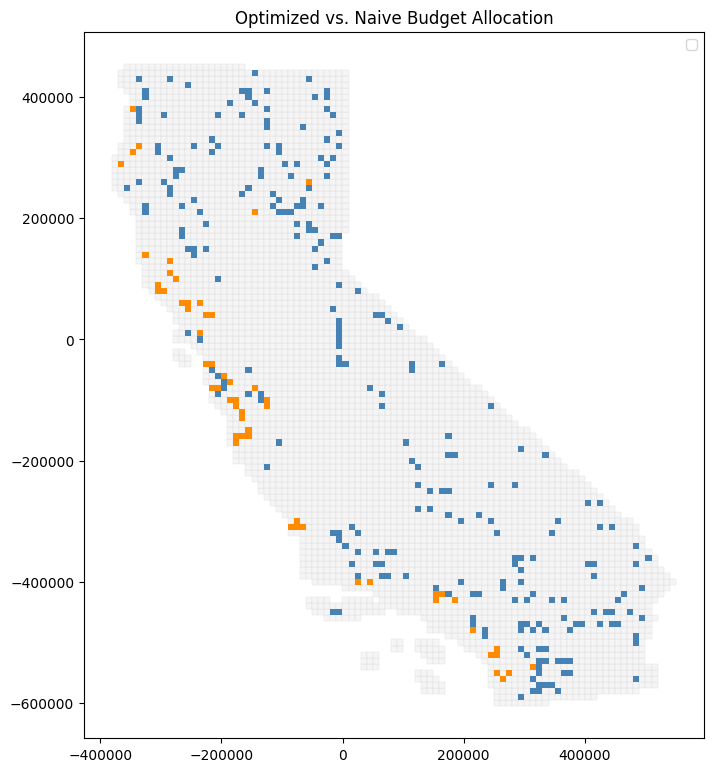

In [52]:
grid["selection_type"] = "Not Selected"
grid.loc[grid["cell_id"].isin(naive_selection["cell_id"]), "selection_type"] = "Naive Top-Ranked"
grid.loc[grid["cell_id"].isin(optimized_v3["cell_id"]), "selection_type"] = "Optimized"

fig, ax = plt.subplots(figsize=(8, 10))
grid[grid["selection_type"] == "Not Selected"].plot(ax=ax, color="whitesmoke", edgecolor="lightgray", linewidth=0.2)
grid[grid["selection_type"] == "Optimized"].plot(ax=ax, color="steelblue", label="Optimized")
grid[grid["selection_type"] == "Naive Top-Ranked"].plot(ax=ax, color="darkorange", label="Naive Top-Ranked")
plt.legend()
plt.title("Optimized vs. Naive Budget Allocation")
plt.show()

In [53]:
presence_coords = list(zip(df["decimalLongitude"], df["decimalLatitude"]))
print(f"Presence points: {len(presence_coords)}")

Presence points: 2349


In [54]:
import numpy as np
from shapely.geometry import Point

ca_outline_wgs84 = ca_outline.to_crs(epsg=4326)
ca_geom_shapely = ca_outline_wgs84.geometry.iloc[0]
minx, miny, maxx, maxy = ca_outline_wgs84.total_bounds

np.random.seed(42)  # reproducibility
n_background = 5000
background_points = []

while len(background_points) < n_background:
    x = np.random.uniform(minx, maxx)
    y = np.random.uniform(miny, maxy)
    pt = Point(x, y)
    if ca_geom_shapely.contains(pt):
        background_points.append((x, y))

print(f"Background points generated: {len(background_points)}")

Background points generated: 5000


In [55]:
import rasterio

raster_files = {
    "mean_temp": "ca_wc2.1_2.5m_bio_1.tif",
    "temp_seasonality": "ca_wc2.1_2.5m_bio_4.tif",
    "annual_precip": "ca_wc2.1_2.5m_bio_12.tif",
    "elevation": "ca_wc2.1_2.5m_elev.tif",
}

def extract_env_values(coords, raster_files, data_dir):
    values = {}
    for col_name, filename in raster_files.items():
        raster_path = os.path.join(data_dir, filename)
        with rasterio.open(raster_path) as src:
            values[col_name] = [v[0] for v in src.sample(coords)]
    return pd.DataFrame(values)

presence_env = extract_env_values(presence_coords, raster_files, data_dir)
presence_env["presence"] = 1

background_env = extract_env_values(background_points, raster_files, data_dir)
background_env["presence"] = 0

print(presence_env.shape, background_env.shape)
print(presence_env.isna().sum())
print(background_env.isna().sum())

(2349, 5) (5000, 5)
mean_temp           0
temp_seasonality    0
annual_precip       0
elevation           0
presence            0
dtype: int64
mean_temp           0
temp_seasonality    0
annual_precip       0
elevation           0
presence            0
dtype: int64


In [56]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_auc_score

# Combine presence and background into one dataset
model_data = pd.concat([presence_env, background_env], ignore_index=True)

feature_cols = ["mean_temp", "temp_seasonality", "annual_precip", "elevation"]
X = model_data[feature_cols]
y = model_data["presence"]

# Train/test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# Train Random Forest
rf = RandomForestClassifier(n_estimators=200, random_state=42, class_weight="balanced")
rf.fit(X_train, y_train)

# Evaluate
y_pred_proba = rf.predict_proba(X_test)[:, 1]
auc = roc_auc_score(y_test, y_pred_proba)
print(f"AUC: {auc:.3f}")

AUC: 0.945


In [57]:
importance = pd.Series(rf.feature_importances_, index=feature_cols).sort_values(ascending=False)
print(importance)

temp_seasonality    0.308948
mean_temp           0.250759
annual_precip       0.248753
elevation           0.191540
dtype: float64


In [58]:
grid_features = grid[feature_cols]
grid["ml_habitat_suitability"] = rf.predict_proba(grid_features)[:, 1]

print(grid["ml_habitat_suitability"].describe())

count    4498.000000
mean        0.134408
std         0.212699
min         0.000000
25%         0.003503
50%         0.040000
75%         0.159330
max         1.000000
Name: ml_habitat_suitability, dtype: float64


Spearman correlation between v1 proxy and v2 ML suitability: 0.406


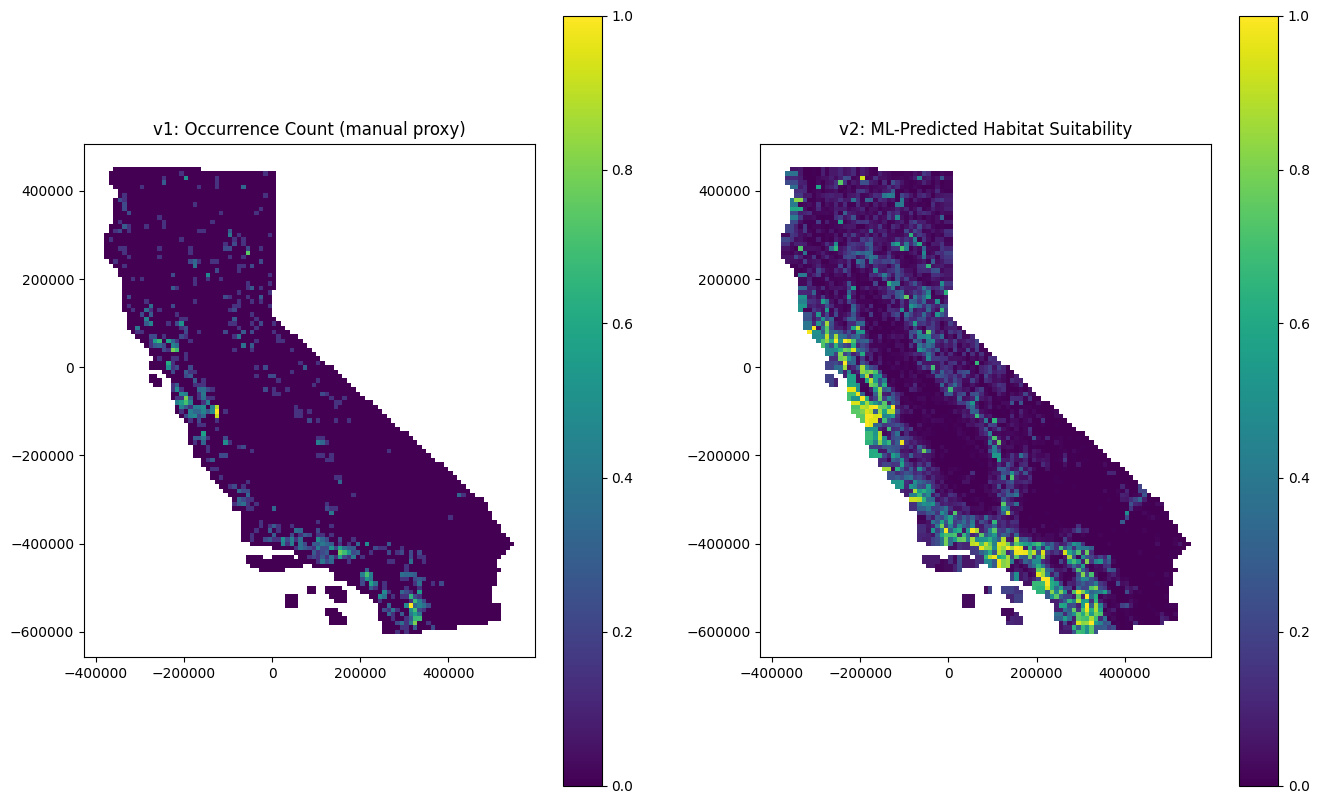

In [59]:
from scipy.stats import spearmanr

correlation, _ = spearmanr(grid["log_occurrence_count_scaled"], grid["ml_habitat_suitability"])
print(f"Spearman correlation between v1 proxy and v2 ML suitability: {correlation:.3f}")

fig, axes = plt.subplots(1, 2, figsize=(16, 10))
grid.plot(column="log_occurrence_count_scaled", cmap="viridis", legend=True, ax=axes[0], edgecolor="none")
axes[0].set_title("v1: Occurrence Count (manual proxy)")
grid.plot(column="ml_habitat_suitability", cmap="viridis", legend=True, ax=axes[1], edgecolor="none")
axes[1].set_title("v2: ML-Predicted Habitat Suitability")
plt.show()

In [60]:
# Keep the v1 score for comparison purposes (already have this as priority_score_100)
grid["priority_score_v1"] = grid["priority_score_100"]

# Rebuild using ML-predicted suitability in place of the manual occurrence proxy
grid["priority_score_v2"] = (
    0.35 * grid["ml_habitat_suitability"]                # ML-predicted habitat suitability
    - 0.25 * grid["fire_frequency_scaled"]                 # wildfire risk (penalize)
    - 0.20 * grid["pct_protected_scaled"]                  # already-protected areas score lower
    + 0.20 * (1 - grid["temp_seasonality_scaled"])         # climate stability
)

# Rescale to 0-100, same as v1, for interpretability and comparability
scaler_v2 = MinMaxScaler(feature_range=(0, 100))
grid["priority_score_v2_100"] = scaler_v2.fit_transform(grid[["priority_score_v2"]])

print(grid["priority_score_v2_100"].describe())

count    4498.000000
mean       41.631191
std        16.255977
min         0.000000
25%        27.836918
50%        41.839929
75%        49.935744
max       100.000000
Name: priority_score_v2_100, dtype: float64


In [61]:
print("=== v1 Top 10 (manual proxy) ===")
print(grid.sort_values("priority_score_v1", ascending=False)[["cell_id", "priority_score_v1"]].head(10))

print("\n=== v2 Top 10 (ML-based) ===")
print(grid.sort_values("priority_score_v2_100", ascending=False)[["cell_id", "priority_score_v2_100"]].head(10))

# How many cells are in both top-10 lists?
top10_v1 = set(grid.sort_values("priority_score_v1", ascending=False).head(10)["cell_id"])
top10_v2 = set(grid.sort_values("priority_score_v2_100", ascending=False).head(10)["cell_id"])
print(f"\nOverlap in top 10: {len(top10_v1 & top10_v2)} cells")

=== v1 Top 10 (manual proxy) ===
      cell_id  priority_score_v1
1170     1170         100.000000
396       396          99.519301
542       542          97.105260
598       598          95.703295
702       702          95.227485
643       643          93.423178
486       486          92.319262
174       174          91.840496
827       827          90.851350
3043     3043          89.735600

=== v2 Top 10 (ML-based) ===
      cell_id  priority_score_v2_100
134       134             100.000000
174       174              99.809252
825       825              98.280114
826       826              98.245072
759       759              98.045017
1447     1447              97.610806
760       760              97.368547
533       533              97.213346
1017     1017              96.343885
2823     2823              96.251458

Overlap in top 10: 1 cells


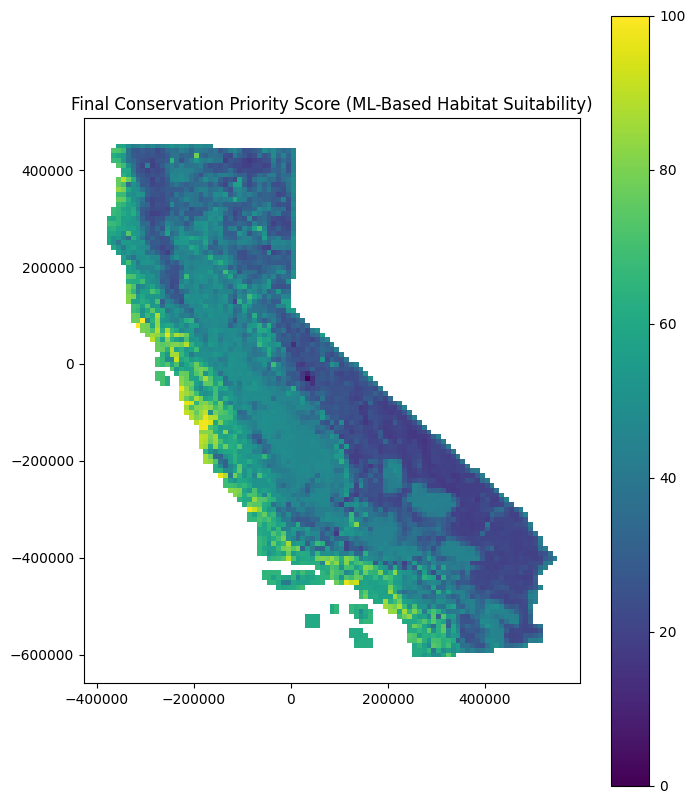

In [62]:
fig, ax = plt.subplots(figsize=(8, 10))
grid.plot(column="priority_score_v2_100", cmap="viridis", legend=True, ax=ax, edgecolor="none")
plt.title("Final Conservation Priority Score (ML-Based Habitat Suitability)")
plt.show()

In [63]:
import rasterio

future_path = os.path.join(data_dir, "wc2.1_2.5m_bioc_MPI-ESM1-2-HR_ssp245_2061-2080.tif")

with rasterio.open(future_path) as src:
    print("Number of bands:", src.count)
    print("CRS:", src.crs)
    print("Shape:", src.shape)
    print("Bounds:", src.bounds)

Number of bands: 19
CRS: EPSG:4326
Shape: (4320, 8640)
Bounds: BoundingBox(left=-180.0, bottom=-89.99999999999997, right=179.99999999999994, top=90.0)


In [64]:
import rasterio
from rasterio.mask import mask

bands_needed = {
    "bio_1": 1,
    "bio_4": 4,
    "bio_12": 12,
}

ca_outline_wgs84 = ca_outline.to_crs(epsg=4326)
ca_geom = [ca_outline_wgs84.geometry.iloc[0]]

for var_name, band_num in bands_needed.items():
    with rasterio.open(future_path) as src:
        out_image, out_transform = mask(src, ca_geom, crop=True, indexes=band_num)
        out_meta = src.meta.copy()
        out_meta.update({
            "count": 1,
            "height": out_image.shape[0] if out_image.ndim == 2 else out_image.shape[1],
            "width": out_image.shape[1] if out_image.ndim == 2 else out_image.shape[2],
            "transform": out_transform
        })

    output_path = os.path.join(data_dir, f"ca_future_{var_name}.tif")

    # Ensure output is 2D→ written as single band
    if out_image.ndim == 2:
        out_image = out_image[np.newaxis, :, :]

    with rasterio.open(output_path, "w", **out_meta) as dest:
        dest.write(out_image)

    print(f"Saved: {output_path}")

Saved: /Users/a.j.sager/Desktop/Climate-Resilience Conservation Project/WorldClim Data/ca_future_bio_1.tif
Saved: /Users/a.j.sager/Desktop/Climate-Resilience Conservation Project/WorldClim Data/ca_future_bio_4.tif
Saved: /Users/a.j.sager/Desktop/Climate-Resilience Conservation Project/WorldClim Data/ca_future_bio_12.tif


In [65]:
future_raster_files = {
    "future_mean_temp": "ca_future_bio_1.tif",
    "future_temp_seasonality": "ca_future_bio_4.tif",
    "future_annual_precip": "ca_future_bio_12.tif",
}

for col_name, filename in future_raster_files.items():
    raster_path = os.path.join(data_dir, filename)
    with rasterio.open(raster_path) as src:
        values = [v[0] for v in src.sample(coords)]
    grid[col_name] = values

# Replace sentinel nodata values with NaN, same as before
for col in future_raster_files.keys():
    grid[col] = grid[col].replace([-3.3999999521443642e+38, -32768], np.nan)

print(grid[list(future_raster_files.keys())].isna().sum())

future_mean_temp           361
future_temp_seasonality    361
future_annual_precip       361
dtype: int64


In [66]:
for col in future_raster_files.keys():
    missing_mask = grid[col].isna()
    if missing_mask.sum() == 0:
        continue
    valid_mask = grid[col].notna()
    tree = cKDTree(xy[valid_mask])
    _, nearest_idx = tree.query(xy[missing_mask])
    valid_values = grid.loc[valid_mask, col].values
    grid.loc[missing_mask, col] = valid_values[nearest_idx]

print(grid[list(future_raster_files.keys())].isna().sum())  # should be all 0

future_mean_temp           0
future_temp_seasonality    0
future_annual_precip       0
dtype: int64


In [67]:
grid["temp_change"] = grid["future_mean_temp"] - grid["mean_temp"]
grid["precip_change"] = grid["future_annual_precip"] - grid["annual_precip"]
grid["precip_change_pct"] = (grid["precip_change"] / grid["annual_precip"]) * 100

print(grid[["temp_change", "precip_change", "precip_change_pct"]].describe())

       temp_change  precip_change  precip_change_pct
count  4498.000000    4498.000000        4498.000000
mean      1.846881       4.738773           1.259840
std       0.207201       7.370829           1.586034
min       1.415667     -23.000000          -3.614458
25%       1.673708       0.000000           0.000000
50%       1.869667       4.000000           1.373005
75%       2.025250      10.000000           2.380952
max       2.233999      29.000000           7.272727


In [68]:
from sklearn.preprocessing import MinMaxScaler

scaler_temp_change = MinMaxScaler()
grid["temp_change_scaled"] = scaler_temp_change.fit_transform(grid[["temp_change"]])

# Rebuild the final priority score, replacing the old seasonality-based
# "climate stability" term with actual projected temperature change
grid["priority_score_v3"] = (
    0.35 * grid["ml_habitat_suitability"]
    - 0.25 * grid["fire_frequency_scaled"]
    - 0.20 * grid["pct_protected_scaled"]
    + 0.20 * (1 - grid["temp_change_scaled"])   # lower projected warming = more resilient
)

scaler_v3 = MinMaxScaler(feature_range=(0, 100))
grid["priority_score_v3_100"] = scaler_v3.fit_transform(grid[["priority_score_v3"]])

print(grid["priority_score_v3_100"].describe())

# Compare v2 vs v3 top 10 overlap, same diagnostic as before
top10_v2 = set(grid.sort_values("priority_score_v2_100", ascending=False).head(10)["cell_id"])
top10_v3 = set(grid.sort_values("priority_score_v3_100", ascending=False).head(10)["cell_id"])
print(f"Overlap between v2 (seasonality-based) and v3 (true future-projection-based) top 10: {len(top10_v2 & top10_v3)} cells")

count    4498.000000
mean       42.050482
std        17.124279
min         0.000000
25%        27.048608
50%        42.146274
75%        53.231213
max       100.000000
Name: priority_score_v3_100, dtype: float64
Overlap between v2 (seasonality-based) and v3 (true future-projection-based) top 10: 8 cells


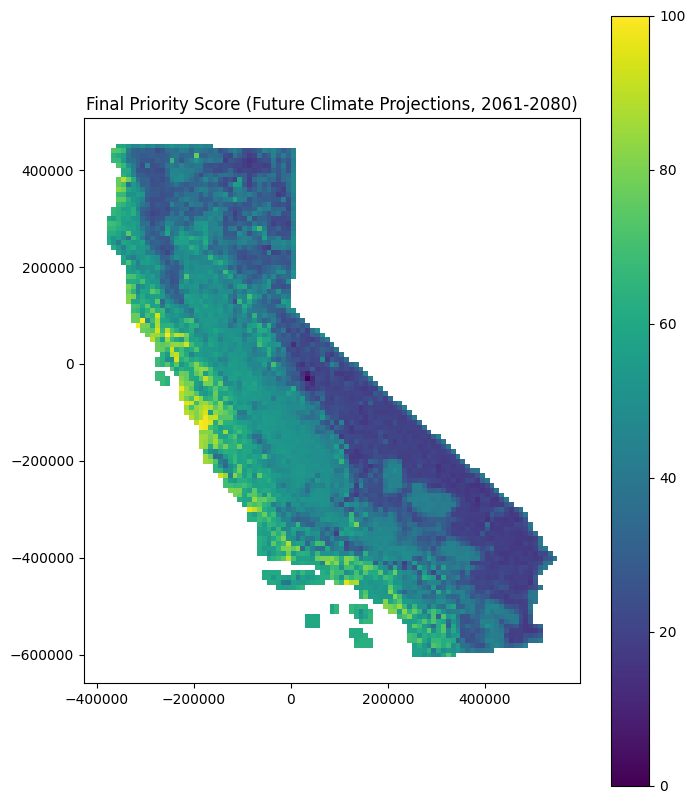

In [69]:
fig, ax = plt.subplots(figsize=(8, 10))
grid.plot(column="priority_score_v3_100", cmap="viridis", legend=True, ax=ax, edgecolor="none")
plt.title("Final Priority Score (Future Climate Projections, 2061-2080)")
plt.show()

In [70]:
# Rebuild candidates using v3 as the priority score
candidates = grid[grid["pct_protected"] < 0.9].copy()
candidates["estimated_cost"] = (candidates["unprotected_acres"] * COST_PER_ACRE) + FIXED_COST_PER_ACQUISITION

cell_ids = candidates["cell_id"].tolist()
select = pulp.LpVariable.dicts("select", cell_ids, cat="Binary")

prob = pulp.LpProblem("Conservation_Budget_Allocation_v3_final", pulp.LpMaximize)

priority_dict = candidates.set_index("cell_id")["priority_score_v3_100"].to_dict()
cost_dict = candidates.set_index("cell_id")["estimated_cost"].to_dict()

prob += pulp.lpSum([select[i] * priority_dict[i] for i in cell_ids])
prob += pulp.lpSum([select[i] * cost_dict[i] for i in cell_ids]) <= BUDGET

prob.solve()

selected_final = [i for i in cell_ids if select[i].varValue == 1]
optimized_final = candidates[candidates["cell_id"].isin(selected_final)]

print("Status:", pulp.LpStatus[prob.status])
print(f"Cells selected: {len(optimized_final)}")
print(f"Total cost: ${optimized_final['estimated_cost'].sum():,.0f}")
print(f"Total priority score: {optimized_final['priority_score_v3_100'].sum():,.0f}")
print(f"Average priority score: {optimized_final['priority_score_v3_100'].mean():.1f}")

Welcome to the CBC MILP Solver 
Version: 2.10.3 
Build Date: Dec 15 2019 

command line - /Users/a.j.sager/anaconda3/lib/python3.11/site-packages/pulp/apis/../solverdir/cbc/osx/i64/cbc /var/folders/rb/s7j0tw914_s4syhm9zgc7gh40000gn/T/02cde5b97a324ffeb7e33f5e42cb3ee2-pulp.mps -max -timeMode elapsed -solve -printingOptions all -solution /var/folders/rb/s7j0tw914_s4syhm9zgc7gh40000gn/T/02cde5b97a324ffeb7e33f5e42cb3ee2-pulp.sol (default strategy 1)
At line 2 NAME          MODEL
At line 3 ROWS
At line 6 COLUMNS
At line 13579 RHS
At line 13581 BOUNDS
At line 16975 ENDATA
Problem MODEL has 1 rows, 3393 columns and 3393 elements
Coin0008I MODEL read with 0 errors
Option for timeMode changed from cpu to elapsed
Continuous objective value is 9428.69 - 0.00 seconds
Cgl0004I processed model has 1 rows, 3372 columns (3372 integer (3356 of which binary)) and 3372 elements
Cbc0038I Initial state - 1 integers unsatisfied sum - 0.054032
Cbc0038I Pass   1: suminf.    0.03845 (1) obj. -9428.61 iterations

In [71]:
grid_sorted_v3 = grid.sort_values("priority_score_v3_100", ascending=False).copy()
grid_sorted_v3["cumulative_cost"] = grid_sorted_v3["estimated_cost"].cumsum()
naive_selection_v3 = grid_sorted_v3[grid_sorted_v3["cumulative_cost"] <= BUDGET]

print(f"Naive cells selected: {len(naive_selection_v3)}")
print(f"Naive total cost: ${naive_selection_v3['estimated_cost'].sum():,.0f}")
print(f"Naive total priority score: {naive_selection_v3['priority_score_v3_100'].sum():,.0f}")
print(f"Naive average priority score: {naive_selection_v3['priority_score_v3_100'].mean():.1f}")

Naive cells selected: 55
Naive total cost: $2,460,495,312
Naive total priority score: 5,025
Naive average priority score: 91.4


EPSG:3310 (7335, 5)


<Axes: >

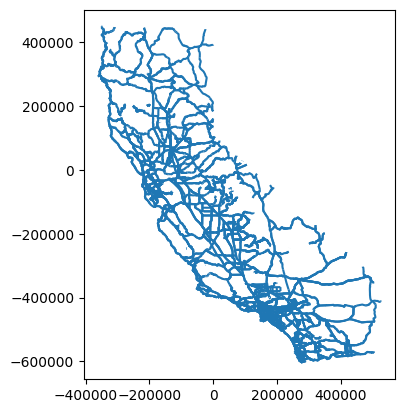

In [73]:
roads = gpd.read_file("/Users/a.j.sager/Desktop/Climate-Resilience Conservation Project/Roads/tl_2025_06_prisecroads.shp")
roads_3310 = roads.to_crs(epsg=3310)

print(roads_3310.crs, roads_3310.shape)
roads_3310.plot()

In [74]:
from shapely.geometry import Point

def compute_road_distance(coords_lonlat, roads_3310):
    pts = gpd.GeoDataFrame(geometry=[Point(xy) for xy in coords_lonlat], crs="EPSG:4326").to_crs(epsg=3310)
    pts["temp_id"] = range(len(pts))
    joined = gpd.sjoin_nearest(pts, roads_3310[["geometry"]], distance_col="dist_to_road_m")
    joined = joined.drop_duplicates(subset="temp_id").sort_values("temp_id")
    return joined["dist_to_road_m"].values

# Grid cells (reuse the same 'coords' variable you already built for raster sampling)
grid["dist_to_road_m"] = compute_road_distance(coords, roads_3310)

# Presence and background points (reuse presence_coords / background_points from your SDM step)
presence_env["dist_to_road_m"] = compute_road_distance(presence_coords, roads_3310)
background_env["dist_to_road_m"] = compute_road_distance(background_points, roads_3310)

print(grid["dist_to_road_m"].describe())

count      4498.000000
mean       9640.103878
std       11428.028781
min           1.145284
25%        2428.286738
50%        6274.440546
75%       12761.174214
max      116370.901500
Name: dist_to_road_m, dtype: float64


In [75]:
print(presence_env["dist_to_road_m"].describe())
print(background_env["dist_to_road_m"].describe())

count     2349.000000
mean      4853.309611
std       4895.455634
min          0.157641
25%       1244.842229
50%       3096.608018
75%       6879.189327
max      30444.975530
Name: dist_to_road_m, dtype: float64
count      5000.000000
mean       8873.710133
std        9882.544757
min           0.028060
25%        2392.599004
50%        5851.616715
75%       11962.013825
max      110384.095034
Name: dist_to_road_m, dtype: float64


In [76]:
# Update feature list to include the new road-distance predictor
feature_cols = ["mean_temp", "temp_seasonality", "annual_precip", "elevation", "dist_to_road_m"]

# Rebuild combined training dataset with the new feature included
model_data = pd.concat([presence_env, background_env], ignore_index=True)
X = model_data[feature_cols]
y = model_data["presence"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

In [77]:
get_ipython().system('pip install xgboost')

In [78]:
from sklearn.linear_model import LogisticRegression
from xgboost import XGBClassifier

models = {
    "Logistic Regression": LogisticRegression(max_iter=1000, class_weight="balanced"),
    "Random Forest": RandomForestClassifier(n_estimators=200, random_state=42, class_weight="balanced"),
    "XGBoost": XGBClassifier(n_estimators=200, random_state=42, eval_metric="logloss"),
}

results = {}
for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred_proba = model.predict_proba(X_test)[:, 1]
    auc = roc_auc_score(y_test, y_pred_proba)
    results[name] = auc
    print(f"{name}: AUC = {auc:.3f}")

/Users/a.j.sager/anaconda3/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:444: ConvergenceWarning: lbfgs failed to converge (status=2):
ABNORMAL_TERMINATION_IN_LNSRCH.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


Logistic Regression: AUC = 0.500
Random Forest: AUC = 0.949
XGBoost: AUC = 0.944


In [79]:
from sklearn.preprocessing import StandardScaler

scaler_lr = StandardScaler()
X_train_scaled = scaler_lr.fit_transform(X_train)
X_test_scaled = scaler_lr.transform(X_test)

log_reg = LogisticRegression(max_iter=1000, class_weight="balanced")
log_reg.fit(X_train_scaled, y_train)
y_pred_proba_lr = log_reg.predict_proba(X_test_scaled)[:, 1]
auc_lr = roc_auc_score(y_test, y_pred_proba_lr)
print(f"Logistic Regression (scaled): AUC = {auc_lr:.3f}")

Logistic Regression (scaled): AUC = 0.635


In [81]:
# Pull the retrained Random Forest directly out of the comparison dictionary
rf = models["Random Forest"]

# Now re-run the prediction
grid_features = grid[feature_cols]
grid["ml_habitat_suitability_v2"] = rf.predict_proba(grid_features)[:, 1]

correlation_v1v2, _ = spearmanr(grid["ml_habitat_suitability"], grid["ml_habitat_suitability_v2"])
print(f"Spearman correlation, ML suitability with vs. without road distance: {correlation_v1v2:.3f}")

top10_old = set(grid.sort_values("ml_habitat_suitability", ascending=False).head(10)["cell_id"])
top10_new = set(grid.sort_values("ml_habitat_suitability_v2", ascending=False).head(10)["cell_id"])
print(f"Top-10 overlap: {len(top10_old & top10_new)} cells")

Spearman correlation, ML suitability with vs. without road distance: 0.900
Top-10 overlap: 5 cells


In [82]:
importance_v2 = pd.Series(rf.feature_importances_, index=feature_cols).sort_values(ascending=False)
print(importance_v2)

# Direction check: does higher suitability correlate with closer or farther from roads?
road_corr, _ = spearmanr(grid["dist_to_road_m"], grid["ml_habitat_suitability_v2"])
print(f"\nCorrelation between distance-to-road and predicted suitability: {road_corr:.3f}")

temp_seasonality    0.264326
annual_precip       0.224855
mean_temp           0.208387
elevation           0.159435
dist_to_road_m      0.142998
dtype: float64

Correlation between distance-to-road and predicted suitability: -0.257


In [83]:
feature_cols_final = ["mean_temp", "temp_seasonality", "annual_precip", "elevation"]

X_final = model_data[feature_cols_final]
X_train_f, X_test_f, y_train_f, y_test_f = train_test_split(X_final, y, test_size=0.2, random_state=42, stratify=y)

rf_final = RandomForestClassifier(n_estimators=200, random_state=42, class_weight="balanced")
rf_final.fit(X_train_f, y_train_f)

auc_final = roc_auc_score(y_test_f, rf_final.predict_proba(X_test_f)[:, 1])
print(f"Final production model AUC (no road distance): {auc_final:.3f}")

rf = rf_final  # restore rf to the version used throughout the rest of your pipeline
grid["ml_habitat_suitability"] = rf.predict_proba(grid[feature_cols_final])[:, 1]

Final production model AUC (no road distance): 0.945


In [84]:
!pip install networkx libpysal

  Obtaining dependency information for libpysal from https://files.pythonhosted.org/packages/0b/d0/a1b09cdea5211f8913406c0560a178fdea6ccbaea4511bbc248e9205f977/libpysal-4.14.1-py3-none-any.whl.metadata
  Obtaining dependency information for beautifulsoup4>=4.13.0 from https://files.pythonhosted.org/packages/88/c6/92fcd42f1ba33e1184263f25bfabf3d27c383410470f169e4b8163bf9c17/beautifulsoup4-4.15.0-py3-none-any.whl.metadata
  Obtaining dependency information for numpy>=1.26.0 from https://files.pythonhosted.org/packages/63/13/f9a8046535cb21deae82f8d03de9617e08882d274fad2539630761888228/numpy-2.4.6-cp311-cp311-macosx_14_0_x86_64.whl.metadata
  Obtaining dependency information for packaging>=23.2 from https://files.pythonhosted.org/packages/df/b2/87e62e8c3e2f4b32e5fe99e0b86d576da1312593b39f47d8ceef365e95ed/packaging-26.2-py3-none-any.whl.metadata
  Obtaining dependency information for platformdirs>=3.11.0 from https://files.pythonhosted.org/packages/7d/68/d8d58938dfb1370b266a1a729e6d77a985be

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 461.0/461.0 kB 38.0 MB/s eta 0:00:00
  Attempting uninstall: platformdirs
    Found existing installation: platformdirs 2.5.2
    Uninstalling platformdirs-2.5.2:
      Successfully uninstalled platformdirs-2.5.2
  Attempting uninstall: packaging
    Found existing installation: packaging 23.0
    Uninstalling packaging-23.0:
      Successfully uninstalled packaging-23.0
  Attempting uninstall: numpy
    Found existing installation: numpy 1.24.3
    Uninstalling numpy-1.24.3:
      Successfully uninstalled numpy-1.24.3
  Attempting uninstall: joblib
    Found existing installation: joblib 1.2.0
    Uninstalling joblib-1.2.0:
      Successfully uninstalled joblib-1.2.0
  Attempting uninstall: beautifulsoup4
    Found existing installation: beautifulsoup4 4.12.2
    Uninstalling beautifulsoup4-4.12.2:
      Successfully uninstalled beautifulsoup4-4.12.2
  Attempting uninstall: scipy
    Found existing installation: scipy 1.10.1
    Uninstalling

In [86]:
import networkx as nx

grid_3310 = grid.to_crs(epsg=3310).reset_index(drop=True)

# Find which cells share a boundary — this replaces libpysal's Queen adjacency
neighbors_df = gpd.sjoin(
    grid_3310[["cell_id", "geometry"]],
    grid_3310[["cell_id", "geometry"]],
    how="left", predicate="touches", lsuffix="left", rsuffix="right"
)
neighbors_df = neighbors_df[neighbors_df["cell_id_left"] != neighbors_df["cell_id_right"]]

print(f"Average neighbors per cell: {neighbors_df.groupby('cell_id_left').size().mean():.1f}")

all_cells = set(grid_3310["cell_id"])
cells_with_neighbors = set(neighbors_df["cell_id_left"].unique())
isolated = all_cells - cells_with_neighbors
print(f"Cells with zero neighbors (isolated): {len(isolated)}")

Average neighbors per cell: 7.7
Cells with zero neighbors (isolated): 0


In [87]:
grid_3310["is_core"] = (grid_3310["ml_habitat_suitability"] > grid_3310["ml_habitat_suitability"].quantile(0.85)) & \
                        (grid_3310["pct_protected"] > 0.3)

core_ids = set(grid_3310.loc[grid_3310["is_core"], "cell_id"])
print(f"Core habitat cells: {len(core_ids)}")

G_core = nx.Graph()
G_core.add_nodes_from(core_ids)

core_edges = neighbors_df[
    neighbors_df["cell_id_left"].isin(core_ids) & neighbors_df["cell_id_right"].isin(core_ids)
]
for _, row in core_edges.iterrows():
    G_core.add_edge(row["cell_id_left"], row["cell_id_right"])

clusters = list(nx.connected_components(G_core))
clusters_sorted = sorted(clusters, key=len, reverse=True)
print(f"Number of distinct core clusters: {len(clusters_sorted)}")
print(f"Sizes of largest 10 clusters: {[len(c) for c in clusters_sorted[:10]]}")

Core habitat cells: 328
Number of distinct core clusters: 77
Sizes of largest 10 clusters: [53, 41, 24, 20, 15, 14, 12, 11, 9, 8]


In [88]:
top_clusters = clusters_sorted[:5]  # the 5 largest core areas

anchors = []
for cluster in top_clusters:
    cluster_cells = grid_3310[grid_3310["cell_id"].isin(cluster)]
    best_cell = cluster_cells.loc[cluster_cells["ml_habitat_suitability"].idxmax()]
    anchors.append(best_cell["cell_id"])

print("Anchor cells (one per major core area):", anchors)
print(grid_3310[grid_3310["cell_id"].isin(anchors)][["cell_id", "ml_habitat_suitability", "pct_protected"]])

Anchor cells (one per major core area): [3792, 2526, 3566, 3044, 702]
      cell_id  ml_habitat_suitability  pct_protected
702       702                 1.00000       0.425746
2526     2526                 0.99000       0.862816
3044     3044                 1.00000       0.796145
3566     3566                 0.94012       0.763170
3792     3792                 1.00000       0.528764


In [89]:
G_full = nx.Graph()

# Resistance: invert suitability so LOW suitability = HIGH cost to traverse
grid_3310["resistance"] = 1.01 - grid_3310["ml_habitat_suitability"]  # avoid exact zero-cost edges

resistance_dict = grid_3310.set_index("cell_id")["resistance"].to_dict()

for _, row in neighbors_df.iterrows():
    c1, c2 = row["cell_id_left"], row["cell_id_right"]
    # Edge cost = average resistance of the two cells being connected
    edge_cost = (resistance_dict[c1] + resistance_dict[c2]) / 2
    G_full.add_edge(c1, c2, weight=edge_cost)

print(f"Graph built: {G_full.number_of_nodes()} nodes, {G_full.number_of_edges()} edges")

Graph built: 4498 nodes, 17364 edges


In [90]:
from itertools import combinations

corridors = {}
for a1, a2 in combinations(anchors, 2):
    path = nx.shortest_path(G_full, source=a1, target=a2, weight="weight")
    path_cost = nx.shortest_path_length(G_full, source=a1, target=a2, weight="weight")
    corridors[(a1, a2)] = {"path": path, "cost": path_cost, "length_cells": len(path)}
    print(f"{a1} -> {a2}: {len(path)} cells, total resistance cost = {path_cost:.2f}")

3792 -> 2526: 32 cells, total resistance cost = 6.05
3792 -> 3566: 11 cells, total resistance cost = 3.72
3792 -> 3044: 20 cells, total resistance cost = 4.08
3792 -> 702: 66 cells, total resistance cost = 18.34
2526 -> 3566: 24 cells, total resistance cost = 5.38
2526 -> 3044: 13 cells, total resistance cost = 1.96
2526 -> 702: 37 cells, total resistance cost = 12.99
3566 -> 3044: 12 cells, total resistance cost = 3.42
3566 -> 702: 58 cells, total resistance cost = 17.67
3044 -> 702: 47 cells, total resistance cost = 14.25


Total unique cells participating in corridor network: 88


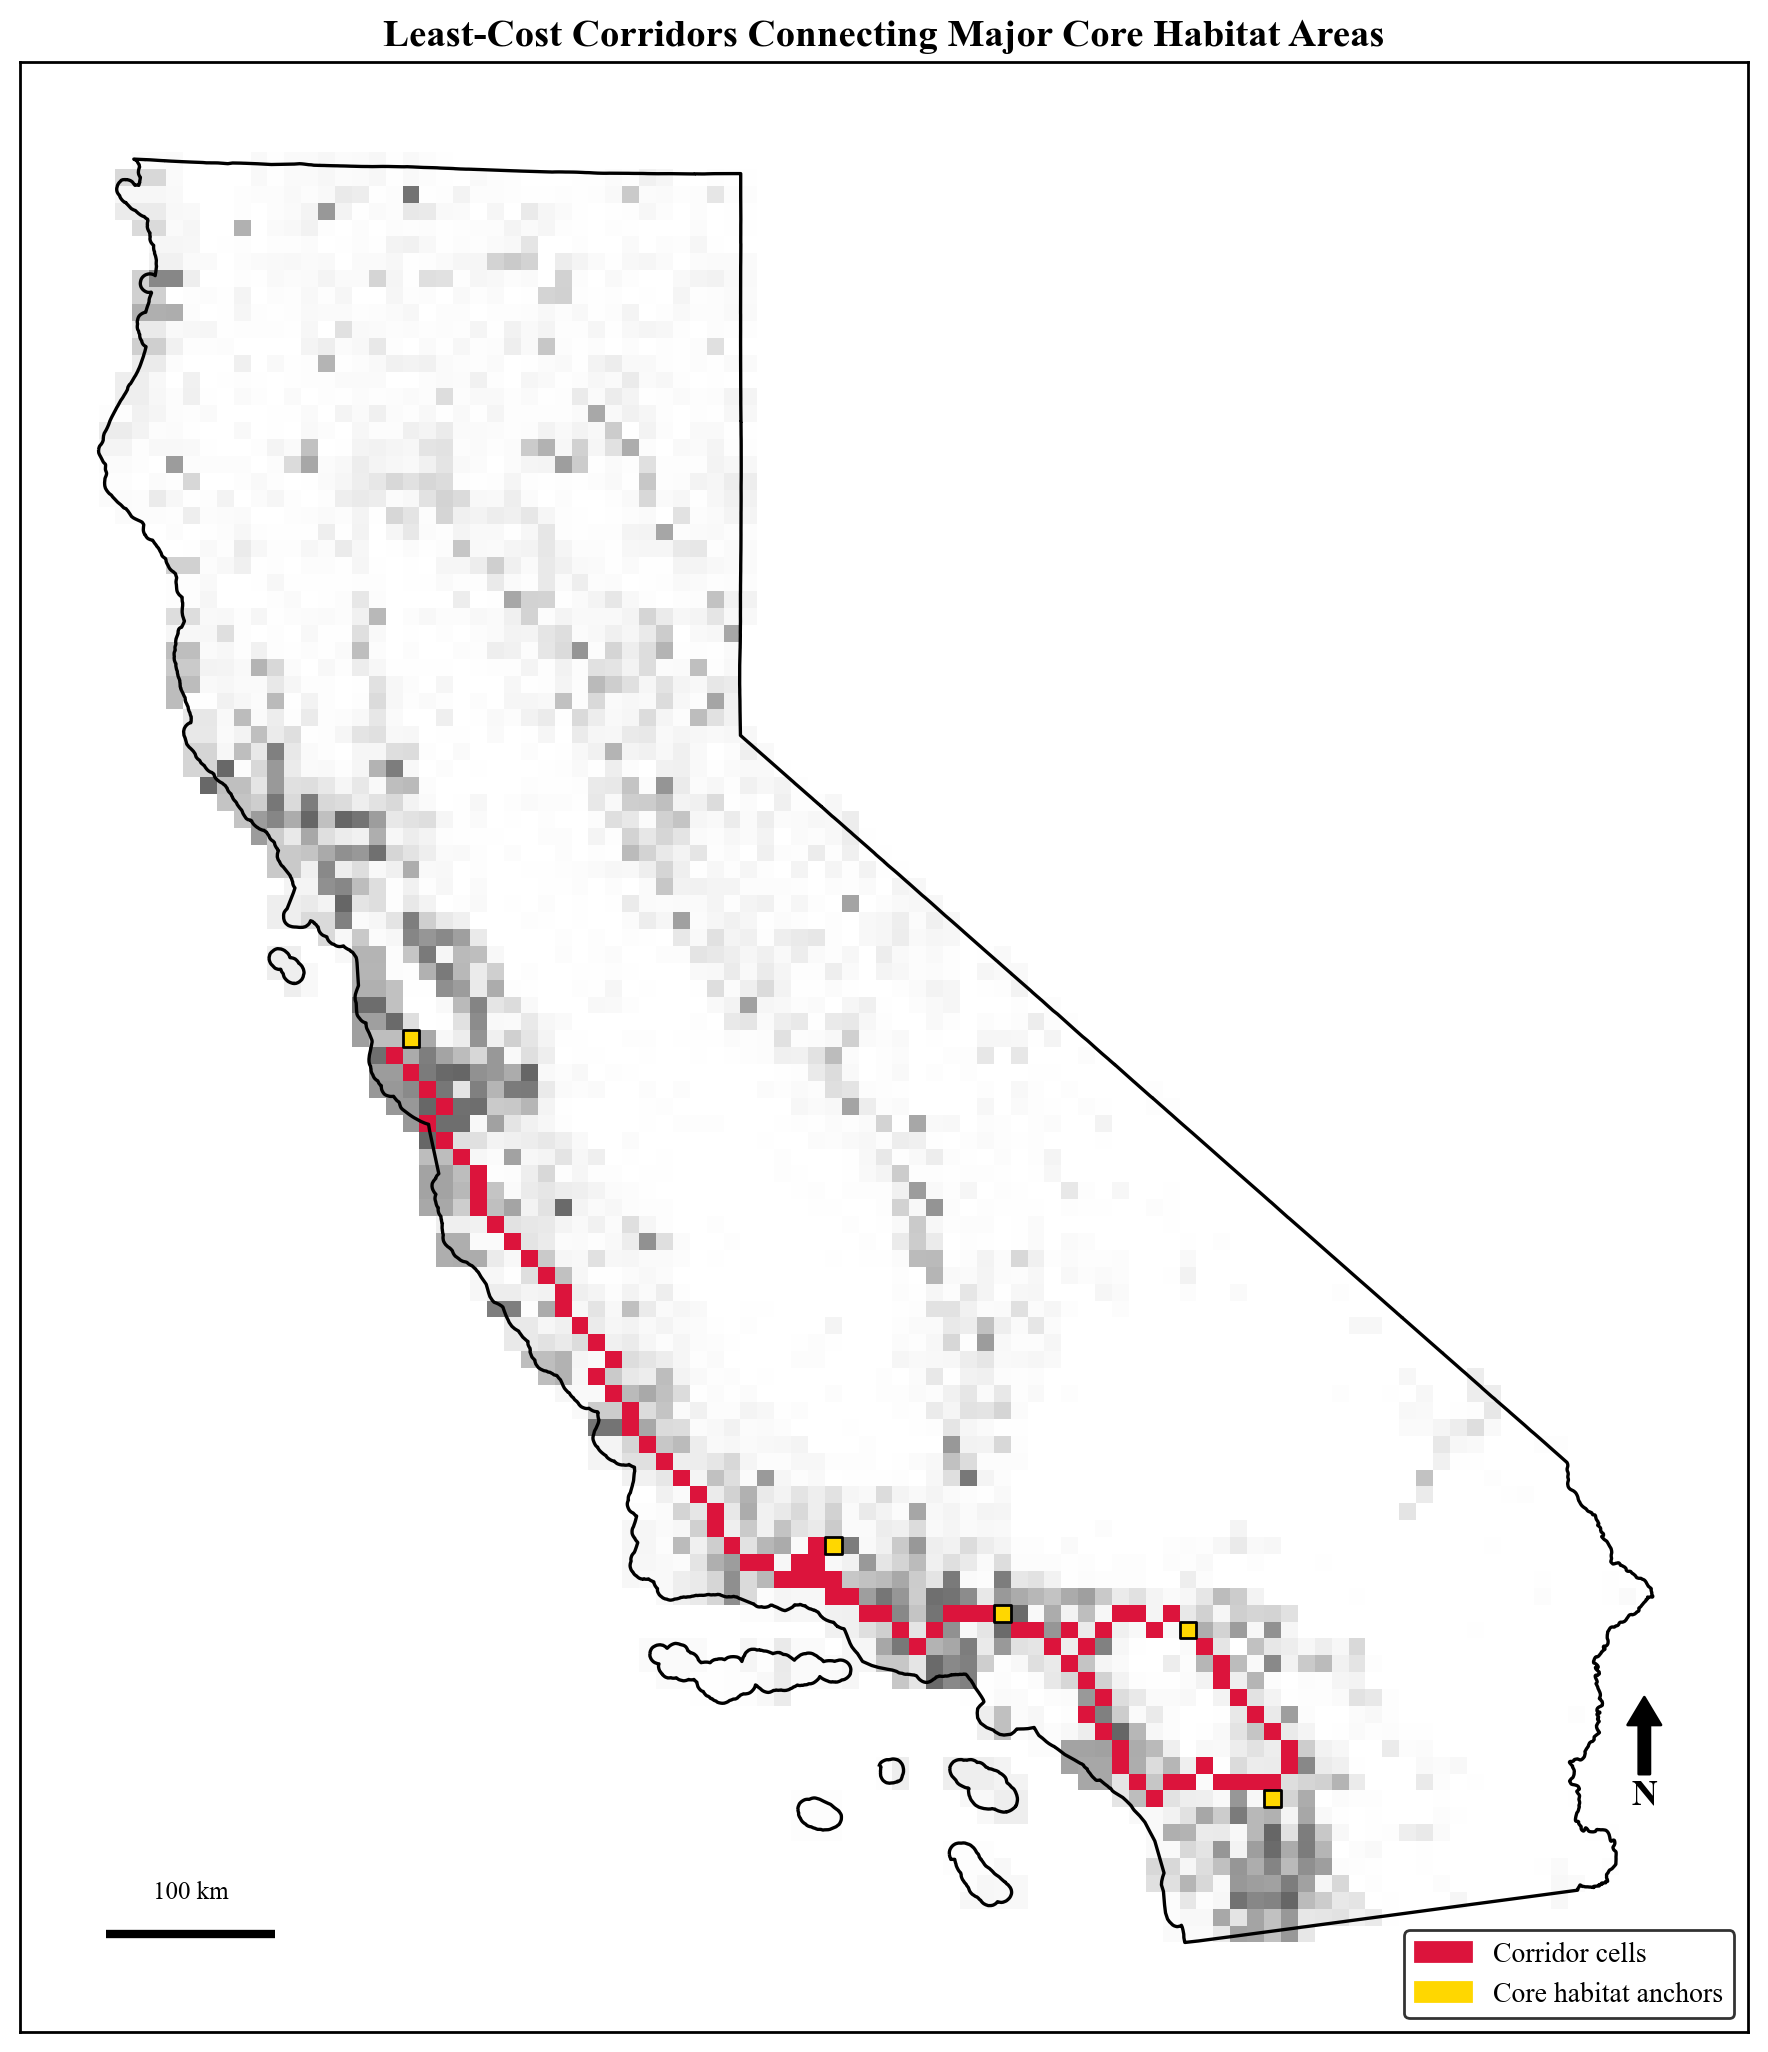

Saved: fig5_corridors.png
Suggested caption: Figure 5. Least-cost corridors (red) connecting the five largest core habitat clusters (gold markers), overlaid on predicted habitat suitability (greyscale).



In [118]:
corridor_cell_ids = set()
for c in corridors.values():
    corridor_cell_ids.update(c["path"])

grid_3310["in_corridor"] = grid_3310["cell_id"].isin(corridor_cell_ids)
grid_3310["is_anchor"] = grid_3310["cell_id"].isin(anchors)

print(f"Total unique cells participating in corridor network: {len(corridor_cell_ids)}")

# ============================================================
# Figure 5 — Least-cost corridors connecting core habitat areas
# (with a crisp state boundary overlay)
# ============================================================
fig, ax = plt.subplots(figsize=(9, 11))

# Backdrop: habitat suitability (soft/blurry by nature — this is expected)
grid_3310.plot(column="ml_habitat_suitability", cmap="Greys", ax=ax, edgecolor="none", alpha=0.6)

# Corridor cells and anchors
grid_3310[grid_3310["in_corridor"]].plot(ax=ax, color="crimson", linewidth=0, label="Corridor cells")
grid_3310[grid_3310["is_anchor"]].plot(ax=ax, color="gold", edgecolor="black", linewidth=1, markersize=80, label="Core habitat anchors")

# Sharp California outline on top — this is the fix
ca_outline_3310 = ca_outline.to_crs(epsg=3310)   # reuse your existing state outline variable
ca_outline_3310.boundary.plot(ax=ax, edgecolor="black", linewidth=1.2, zorder=5)

ax.set_title("Least-Cost Corridors Connecting Major Core Habitat Areas")
clean_axes(ax)
add_north_arrow(ax)
add_scale_bar(ax, length_km=100)

corridor_patch = mpatches.Patch(color="crimson", label="Corridor cells")
anchor_patch = mpatches.Patch(color="gold", label="Core habitat anchors")
ax.legend(handles=[corridor_patch, anchor_patch], loc="lower right")

finalize_and_save(
    fig, "fig5_corridors",
    "Figure 5. Least-cost corridors (red) connecting the five largest core habitat clusters "
    "(gold markers), overlaid on predicted habitat suitability (greyscale)."
)

In [92]:
from collections import Counter

usage_counter = Counter()
for c in corridors.values():
    usage_counter.update(c["path"])

grid_3310["corridor_usage"] = grid_3310["cell_id"].map(usage_counter).fillna(0)
print(grid_3310["corridor_usage"].value_counts().sort_index(ascending=False).head(10))

corridor_usage
8       1
6      12
4      37
3      27
1      11
0    4410
Name: count, dtype: int64


In [93]:
corridor_cells = grid_3310[grid_3310["in_corridor"]]
pct_unprotected = (corridor_cells["pct_protected"] < 0.3).mean() * 100
print(f"Of {len(corridor_cells)} corridor cells, {pct_unprotected:.1f}% have less than 30% existing protection")

Of 88 corridor cells, 47.7% have less than 30% existing protection


In [94]:
# Merge corridor results back onto the main grid (not just the reprojected copy)
grid = grid.merge(
    grid_3310[["cell_id", "corridor_usage", "in_corridor"]],
    on="cell_id", how="left"
)
grid["corridor_usage"] = grid["corridor_usage"].fillna(0)

# Scale corridor usage 0-1
scaler_corridor = MinMaxScaler()
grid["corridor_usage_scaled"] = scaler_corridor.fit_transform(grid[["corridor_usage"]])

# Rebalanced v4 formula: habitat, connectivity, fire, protection, climate resilience
grid["priority_score_v4"] = (
    0.30 * grid["ml_habitat_suitability"]
    + 0.15 * grid["corridor_usage_scaled"]        # NEW: connectivity bonus
    - 0.20 * grid["fire_frequency_scaled"]
    - 0.15 * grid["pct_protected_scaled"]
    + 0.20 * (1 - grid["temp_change_scaled"])
)

scaler_v4 = MinMaxScaler(feature_range=(0, 100))
grid["priority_score_v4_100"] = scaler_v4.fit_transform(grid[["priority_score_v4"]])

print(grid["priority_score_v4_100"].describe())

top10_v3 = set(grid.sort_values("priority_score_v3_100", ascending=False).head(10)["cell_id"])
top10_v4 = set(grid.sort_values("priority_score_v4_100", ascending=False).head(10)["cell_id"])
print(f"Overlap between v3 and v4 (connectivity-aware) top 10: {len(top10_v3 & top10_v4)} cells")

count    4498.000000
mean       36.796707
std        16.273158
min         0.000000
25%        23.217707
50%        36.029528
75%        46.849753
max       100.000000
Name: priority_score_v4_100, dtype: float64
Overlap between v3 and v4 (connectivity-aware) top 10: 6 cells


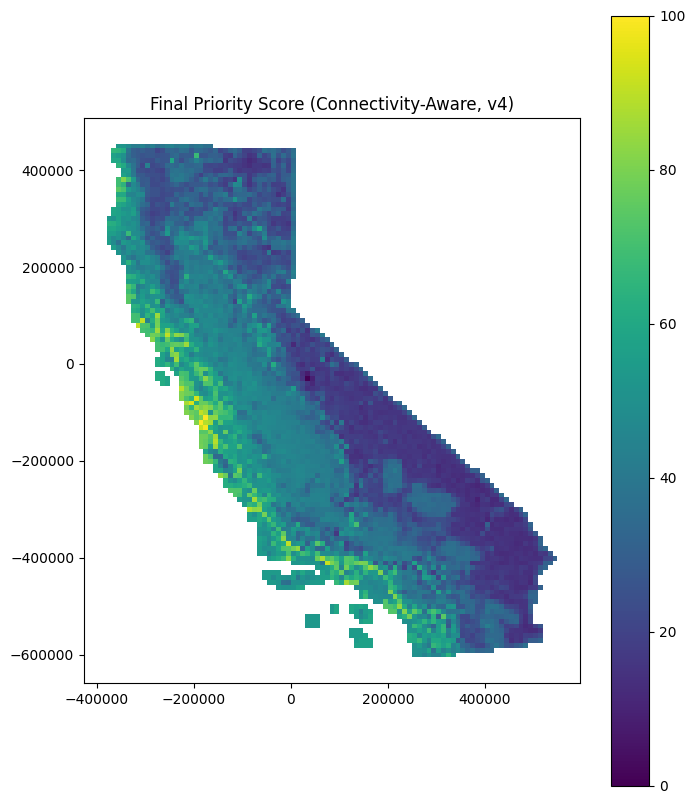

In [95]:
fig, ax = plt.subplots(figsize=(8, 10))
grid.plot(column="priority_score_v4_100", cmap="viridis", legend=True, ax=ax, edgecolor="none")
plt.title("Final Priority Score (Connectivity-Aware, v4)")
plt.show()

In [96]:
candidates = grid[grid["pct_protected"] < 0.9].copy()
candidates["estimated_cost"] = (candidates["unprotected_acres"] * COST_PER_ACRE) + FIXED_COST_PER_ACQUISITION

cell_ids = candidates["cell_id"].tolist()
select = pulp.LpVariable.dicts("select", cell_ids, cat="Binary")

prob = pulp.LpProblem("Conservation_Budget_Allocation_v4_final", pulp.LpMaximize)

priority_dict = candidates.set_index("cell_id")["priority_score_v4_100"].to_dict()
cost_dict = candidates.set_index("cell_id")["estimated_cost"].to_dict()

prob += pulp.lpSum([select[i] * priority_dict[i] for i in cell_ids])
prob += pulp.lpSum([select[i] * cost_dict[i] for i in cell_ids]) <= BUDGET

prob.solve()

selected_v4 = [i for i in cell_ids if select[i].varValue == 1]
optimized_v4 = candidates[candidates["cell_id"].isin(selected_v4)]

print("Status:", pulp.LpStatus[prob.status])
print(f"Cells selected: {len(optimized_v4)}")
print(f"Total cost: ${optimized_v4['estimated_cost'].sum():,.0f}")
print(f"Total priority score: {optimized_v4['priority_score_v4_100'].sum():,.0f}")
print(f"Average priority score: {optimized_v4['priority_score_v4_100'].mean():.1f}")

grid_sorted_v4 = grid.sort_values("priority_score_v4_100", ascending=False).copy()
grid_sorted_v4["cumulative_cost"] = grid_sorted_v4["estimated_cost"].cumsum()
naive_selection_v4 = grid_sorted_v4[grid_sorted_v4["cumulative_cost"] <= BUDGET]

print(f"\nNaive cells selected: {len(naive_selection_v4)}")
print(f"Naive total cost: ${naive_selection_v4['estimated_cost'].sum():,.0f}")
print(f"Naive total priority score: {naive_selection_v4['priority_score_v4_100'].sum():,.0f}")
print(f"Naive average priority score: {naive_selection_v4['priority_score_v4_100'].mean():.1f}")

# Bonus: what % of the OPTIMIZED selection's land falls inside identified corridors?
optimized_corridor_pct = optimized_v4["cell_id"].isin(corridor_cell_ids).mean() * 100
print(f"\n% of optimized selection that is corridor land: {optimized_corridor_pct:.1f}%")

Welcome to the CBC MILP Solver 
Version: 2.10.3 
Build Date: Dec 15 2019 

command line - /Users/a.j.sager/anaconda3/lib/python3.11/site-packages/pulp/apis/../solverdir/cbc/osx/i64/cbc /var/folders/rb/s7j0tw914_s4syhm9zgc7gh40000gn/T/e4997edcce7d43628be5b6f2c0c16fca-pulp.mps -max -timeMode elapsed -solve -printingOptions all -solution /var/folders/rb/s7j0tw914_s4syhm9zgc7gh40000gn/T/e4997edcce7d43628be5b6f2c0c16fca-pulp.sol (default strategy 1)
At line 2 NAME          MODEL
At line 3 ROWS
At line 6 COLUMNS
At line 13579 RHS
At line 13581 BOUNDS
At line 16975 ENDATA
Problem MODEL has 1 rows, 3393 columns and 3393 elements
Coin0008I MODEL read with 0 errors
Option for timeMode changed from cpu to elapsed
Continuous objective value is 8686.24 - 0.00 seconds
Cgl0004I processed model has 1 rows, 3372 columns (3372 integer (3356 of which binary)) and 3372 elements
Cbc0038I Initial state - 1 integers unsatisfied sum - 0.34043
Cbc0038I Solution found of -8657.91
Cbc0038I Cleaned solution of -8

In [97]:
import numpy as np

# Assign each point (presence + background) to a spatial block based on its grid cell
model_data_coords = pd.concat([
    pd.DataFrame({"lon": [c[0] for c in presence_coords], "lat": [c[1] for c in presence_coords]}),
    pd.DataFrame({"lon": [c[0] for c in background_points], "lat": [c[1] for c in background_points]})
], ignore_index=True)

# Build a coarse spatial block grid (larger than your 10km analysis grid — e.g. 50km blocks)
# so entire clusters of points fall together
block_size_deg = 0.5  # roughly 50km at CA's latitude
model_data["block_x"] = (model_data_coords["lon"] // block_size_deg).astype(int)
model_data["block_y"] = (model_data_coords["lat"] // block_size_deg).astype(int)
model_data["block_id"] = model_data["block_x"].astype(str) + "_" + model_data["block_y"].astype(str)

print(f"Number of spatial blocks: {model_data['block_id'].nunique()}")
print(model_data.groupby("block_id").size().describe())

Number of spatial blocks: 205
count    205.000000
mean      35.848780
std       36.015677
min        1.000000
25%       22.000000
50%       31.000000
75%       38.000000
max      339.000000
dtype: float64


In [98]:
from sklearn.model_selection import train_test_split as tts

feature_cols_final = ["mean_temp", "temp_seasonality", "annual_precip", "elevation"]

# Split by BLOCK, not by individual point — this is what makes it spatially valid
unique_blocks = model_data["block_id"].unique()
train_blocks, test_blocks = tts(unique_blocks, test_size=0.2, random_state=42)

train_mask = model_data["block_id"].isin(train_blocks)
test_mask = model_data["block_id"].isin(test_blocks)

X_train_sp = model_data.loc[train_mask, feature_cols_final]
X_test_sp = model_data.loc[test_mask, feature_cols_final]
y_train_sp = model_data.loc[train_mask, "presence"]
y_test_sp = model_data.loc[test_mask, "presence"]

print(f"Train: {len(X_train_sp)} points ({y_train_sp.sum()} presence, {len(y_train_sp)-y_train_sp.sum()} background)")
print(f"Test: {len(X_test_sp)} points ({y_test_sp.sum()} presence, {len(y_test_sp)-y_test_sp.sum()} background)")

rf_spatial = RandomForestClassifier(n_estimators=200, random_state=42, class_weight="balanced")
rf_spatial.fit(X_train_sp, y_train_sp)

auc_spatial = roc_auc_score(y_test_sp, rf_spatial.predict_proba(X_test_sp)[:, 1])
print(f"\nSpatial block-based AUC: {auc_spatial:.3f}")
print(f"Original random-split AUC (for comparison): 0.945")

Train: 5834 points (1897 presence, 3937 background)
Test: 1515 points (452 presence, 1063 background)

Spatial block-based AUC: 0.841
Original random-split AUC (for comparison): 0.945


In [99]:
# This becomes your primary, reported model going forward
rf = rf_spatial

grid["ml_habitat_suitability"] = rf.predict_proba(grid[feature_cols_final])[:, 1]

# Confirm downstream results barely shift (expected, since underlying model is similar in structure)
print(grid["ml_habitat_suitability"].describe())

count    4498.000000
mean        0.131440
std         0.208110
min         0.000000
25%         0.002045
50%         0.040000
75%         0.156848
max         1.000000
Name: ml_habitat_suitability, dtype: float64


In [100]:
import numpy as np

np.random.seed(42)
n_simulations = 500
top_n = 50  # "high priority" = top 50 cells (~top 1%)

# Pull out each score component (already 0-1 scaled from your v4 work)
components = {
    "habitat": grid["ml_habitat_suitability"].values,
    "corridor": grid["corridor_usage_scaled"].values,
    "fire": grid["fire_frequency_scaled"].values,          # subtracted
    "protection": grid["pct_protected_scaled"].values,     # subtracted
    "climate": (1 - grid["temp_change_scaled"]).values,
}

n_cells = len(grid)
appearance_counts = np.zeros(n_cells)

for i in range(n_simulations):
    # Dirichlet draw: 5 random weights that always sum to 1, but vary each run
    w_habitat, w_corridor, w_fire, w_protection, w_climate = np.random.dirichlet(np.ones(5))

    score = (
        w_habitat * components["habitat"]
        + w_corridor * components["corridor"]
        - w_fire * components["fire"]
        - w_protection * components["protection"]
        + w_climate * components["climate"]
    )

    top_idx = np.argsort(score)[-top_n:]
    appearance_counts[top_idx] += 1

grid["sensitivity_frequency"] = appearance_counts / n_simulations

print(grid["sensitivity_frequency"].describe())
print(f"\nCells in top {top_n} across ALL {n_simulations} random weightings: {(appearance_counts == n_simulations).sum()}")
print(f"Cells in top {top_n} in \u226590% of weightings: {(grid['sensitivity_frequency'] >= 0.9).sum()}")
print(f"Cells in top {top_n} in \u226550% of weightings: {(grid['sensitivity_frequency'] >= 0.5).sum()}")

# How much does your original chosen weighting agree with the robust set?
original_top50 = set(grid.sort_values("priority_score_v4_100", ascending=False).head(50)["cell_id"])
robust_cells = set(grid[grid["sensitivity_frequency"] >= 0.9]["cell_id"])
print(f"\nOverlap between your original v4 top-50 and the \u226590%-robust cells: {len(original_top50 & robust_cells)}")

count    4498.000000
mean        0.011116
std         0.072012
min         0.000000
25%         0.000000
50%         0.000000
75%         0.000000
max         0.998000
Name: sensitivity_frequency, dtype: float64

Cells in top 50 across ALL 500 random weightings: 0
Cells in top 50 in ≥90% of weightings: 4
Cells in top 50 in ≥50% of weightings: 31

Overlap between your original v4 top-50 and the ≥90%-robust cells: 4


     cell_id  sensitivity_frequency  priority_score_v4_100  \
643      643                  0.900              94.260659   
760      760                  0.996             100.000000   
825      825                  0.998              98.297168   
827      827                  0.990              99.360445   

     ml_habitat_suitability  pct_protected  fire_frequency  
643                0.947087       0.158753               1  
760                0.995000       0.028700               0  
825                0.915000       0.000000               0  
827                0.990000       0.087425               0  


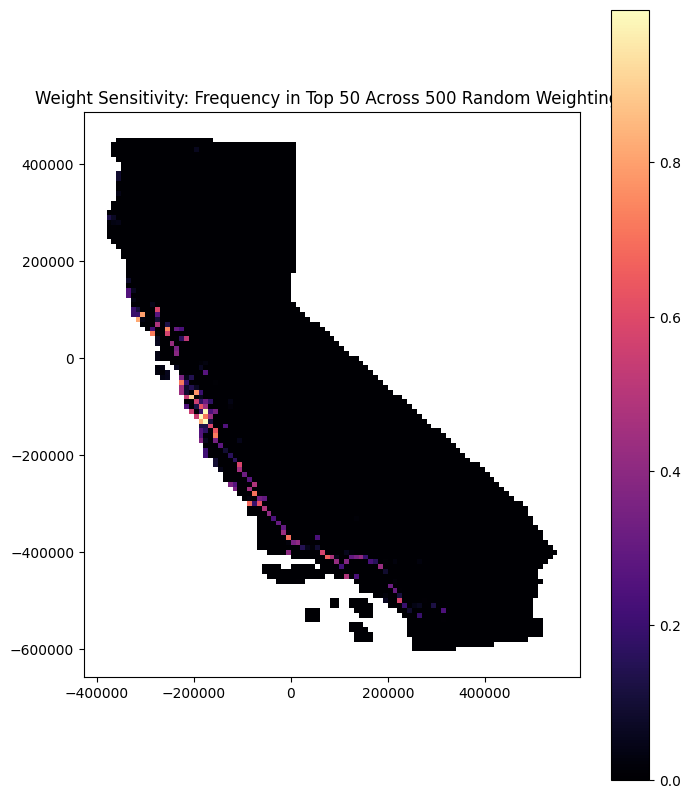

In [101]:
robust_core = grid[grid["sensitivity_frequency"] >= 0.9][["cell_id", "sensitivity_frequency", "priority_score_v4_100", "ml_habitat_suitability", "pct_protected", "fire_frequency"]]
print(robust_core)

fig, ax = plt.subplots(figsize=(8, 10))
grid.plot(column="sensitivity_frequency", cmap="magma", legend=True, ax=ax, edgecolor="none")
plt.title("Weight Sensitivity: Frequency in Top 50 Across 500 Random Weightings")
plt.show()

EPSG:3857 (121901, 36)
['OBJECTID', 'Hex_ID', 'HUC12', 'Name', 'SpBioRnkEc', 'SpBioWtEco', 'SpBioRnkSW', 'BioTrRnkEc', 'BioTrRnkSW', 'BioAqRnkSW', 'NtvSpRnkEc', 'NtvSpRnkSW', 'NtvTrRnkEc', 'NtvTrRnkSW', 'NtvAqRnkSW', 'RarRnkEco', 'RarRnkSW', 'RarTrRnkEc', 'RarTrRnkSW', 'RarAqRnkSW', 'RwiRankEco', 'RwiRankSW', 'RwiTrRnkEc', 'RwiTrRnkSW', 'RwiAqRnkSW', 'TerrConnRa', 'TerrClimRa', 'TerrHabRan', 'AqHabRank', 'Eco_Sect', 'Eco_Name', 'Jepson_Eco', 'County', 'Shape__Are', 'Shape__Len', 'geometry']


<Axes: >

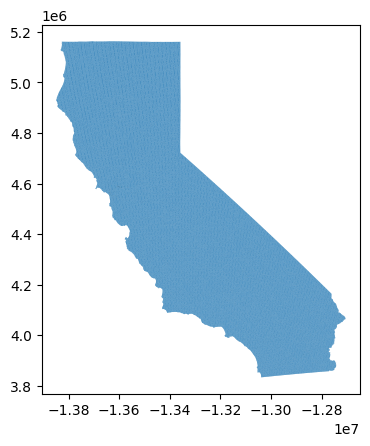

In [102]:
ace = gpd.read_file("/Users/a.j.sager/Desktop/Climate-Resilience Conservation Project/ACE Validation Species/Species_Biodiversity_-_ACE_[ds2769].shp")

print(ace.crs, ace.shape)
print(ace.columns.tolist())
ace.plot()

In [103]:
# Reproject to match your grid's CRS
ace_3310 = ace.to_crs(epsg=3310)

# Use grid cell centroids for the spatial join (since ACE hexagons and your square grid don't align)
grid_centroids = grid.copy()
grid_centroids["geometry"] = grid_3310.geometry.centroid

ace_joined = gpd.sjoin(
    grid_centroids[["cell_id", "geometry"]],
    ace_3310[["SpBioRnkSW", "TerrConnRa", "geometry"]],
    how="left", predicate="within"
)

print(f"Grid cells matched to an ACE hexagon: {ace_joined['SpBioRnkSW'].notna().sum()} out of {len(grid)}")

# Merge back onto main grid
grid = grid.merge(
    ace_joined[["cell_id", "SpBioRnkSW", "TerrConnRa"]].drop_duplicates(subset="cell_id"),
    on="cell_id", how="left"
)

print(grid["SpBioRnkSW"].value_counts(dropna=False).sort_index())
print(grid["TerrConnRa"].value_counts(dropna=False).sort_index())

Grid cells matched to an ACE hexagon: 4099 out of 4498
SpBioRnkSW
1.0    1163
2.0     746
3.0     667
4.0     673
5.0     850
NaN     399
Name: count, dtype: int64
TerrConnRa
1.0     788
2.0     750
3.0    1276
4.0     942
5.0     339
NaN     403
Name: count, dtype: int64


In [104]:
from scipy.stats import spearmanr

# Only compare where we have a real ACE match
valid = grid.dropna(subset=["SpBioRnkSW", "TerrConnRa"])

# 1. Overall priority score vs. ACE's independent biodiversity rank
corr_biodiversity, _ = spearmanr(valid["priority_score_v4_100"], valid["SpBioRnkSW"])
print(f"Spearman correlation: your priority score vs. ACE species biodiversity rank: {corr_biodiversity:.3f}")

# 2. Corridor usage vs. ACE's independent connectivity rank — validates Section 3.6 specifically
corr_connectivity, _ = spearmanr(valid["corridor_usage"], valid["TerrConnRa"])
print(f"Spearman correlation: your corridor usage vs. ACE connectivity rank: {corr_connectivity:.3f}")

# 3. Do your top-priority cells land in ACE's own top biodiversity tier (rank 4-5)?
your_top_10pct = valid.sort_values("priority_score_v4_100", ascending=False).head(int(len(valid) * 0.1))
pct_in_ace_top_tier = (your_top_10pct["SpBioRnkSW"] >= 4).mean() * 100
baseline_top_tier_rate = (valid["SpBioRnkSW"] >= 4).mean() * 100

print(f"\n% of your top-10% priority cells that ACE also ranks 4-5 (top tier): {pct_in_ace_top_tier:.1f}%")
print(f"Baseline rate of ACE rank 4-5 across ALL matched cells: {baseline_top_tier_rate:.1f}%")

# 4. Same check for corridors specifically
your_corridor_cells = valid[valid["in_corridor"] == True]
pct_corridor_in_ace_top = (your_corridor_cells["TerrConnRa"] >= 4).mean() * 100
baseline_conn_top_rate = (valid["TerrConnRa"] >= 4).mean() * 100
print(f"\n% of your identified corridor cells that ACE also ranks 4-5 connectivity: {pct_corridor_in_ace_top:.1f}%")
print(f"Baseline rate of ACE rank 4-5 connectivity across ALL matched cells: {baseline_conn_top_rate:.1f}%")

Spearman correlation: your priority score vs. ACE species biodiversity rank: 0.426
Spearman correlation: your corridor usage vs. ACE connectivity rank: 0.046

% of your top-10% priority cells that ACE also ranks 4-5 (top tier): 78.5%
Baseline rate of ACE rank 4-5 across ALL matched cells: 37.2%

% of your identified corridor cells that ACE also ranks 4-5 connectivity: 38.8%
Baseline rate of ACE rank 4-5 connectivity across ALL matched cells: 31.3%


In [106]:
budget_scenarios = {
    "-10%": ("minus10", BUDGET * 0.9),
    "Base": ("base", BUDGET),
    "+10%": ("plus10", BUDGET * 1.1),
    "+25%": ("plus25", BUDGET * 1.25),
}

scenario_selections = {}

for label, (safe_name, b) in budget_scenarios.items():
    prob_s = pulp.LpProblem(f"Budget_{safe_name}", pulp.LpMaximize)
    select_s = pulp.LpVariable.dicts(f"select_{safe_name}", cell_ids, cat="Binary")
    prob_s += pulp.lpSum([select_s[i] * priority_dict[i] for i in cell_ids])
    prob_s += pulp.lpSum([select_s[i] * cost_dict[i] for i in cell_ids]) <= b
    prob_s.solve()
    selected = set(i for i in cell_ids if select_s[i].varValue == 1)
    scenario_selections[label] = selected
    print(f"{label}: {len(selected)} cells, budget ${b:,.0f}")

added_10pct = scenario_selections["+10%"] - scenario_selections["Base"]
print(f"\nCells added at +10% budget: {len(added_10pct)}")
print(f"Average priority score of newly-added cells: {candidates[candidates['cell_id'].isin(added_10pct)]['priority_score_v4_100'].mean():.1f}")
print(f"Average priority score of the base selection: {candidates[candidates['cell_id'].isin(scenario_selections['Base'])]['priority_score_v4_100'].mean():.1f}")

Welcome to the CBC MILP Solver 
Version: 2.10.3 
Build Date: Dec 15 2019 

command line - /Users/a.j.sager/anaconda3/lib/python3.11/site-packages/pulp/apis/../solverdir/cbc/osx/i64/cbc /var/folders/rb/s7j0tw914_s4syhm9zgc7gh40000gn/T/d8c40a96e3894a809f276b1808ad2ff4-pulp.mps -max -timeMode elapsed -solve -printingOptions all -solution /var/folders/rb/s7j0tw914_s4syhm9zgc7gh40000gn/T/d8c40a96e3894a809f276b1808ad2ff4-pulp.sol (default strategy 1)
At line 2 NAME          MODEL
At line 3 ROWS
At line 6 COLUMNS
At line 13579 RHS
At line 13581 BOUNDS
At line 16975 ENDATA
Problem MODEL has 1 rows, 3393 columns and 3393 elements
Coin0008I MODEL read with 0 errors
Option for timeMode changed from cpu to elapsed
Continuous objective value is 8011.13 - 0.00 seconds
Cgl0004I processed model has 1 rows, 3372 columns (3372 integer (3356 of which binary)) and 3372 elements
Cbc0038I Initial state - 1 integers unsatisfied sum - 0.421555
Cbc0038I Pass   1: suminf.    0.40153 (1) obj. -8007.26 iterations

Welcome to the CBC MILP Solver 
Version: 2.10.3 
Build Date: Dec 15 2019 

command line - /Users/a.j.sager/anaconda3/lib/python3.11/site-packages/pulp/apis/../solverdir/cbc/osx/i64/cbc /var/folders/rb/s7j0tw914_s4syhm9zgc7gh40000gn/T/453e6833a6b44d51a158395f2deb4067-pulp.mps -max -timeMode elapsed -solve -printingOptions all -solution /var/folders/rb/s7j0tw914_s4syhm9zgc7gh40000gn/T/453e6833a6b44d51a158395f2deb4067-pulp.sol (default strategy 1)
At line 2 NAME          MODEL
At line 3 ROWS
At line 6 COLUMNS
At line 13579 RHS
At line 13581 BOUNDS
At line 16975 ENDATA
Problem MODEL has 1 rows, 3393 columns and 3393 elements
Coin0008I MODEL read with 0 errors
Option for timeMode changed from cpu to elapsed
Continuous objective value is 8686.24 - 0.00 seconds
Cgl0004I processed model has 1 rows, 3372 columns (3372 integer (3356 of which binary)) and 3372 elements
Cbc0038I Initial state - 1 integers unsatisfied sum - 0.34043
Cbc0038I Solution found of -8657.91
Cbc0038I Cleaned solution of -8

Welcome to the CBC MILP Solver 
Version: 2.10.3 
Build Date: Dec 15 2019 

command line - /Users/a.j.sager/anaconda3/lib/python3.11/site-packages/pulp/apis/../solverdir/cbc/osx/i64/cbc /var/folders/rb/s7j0tw914_s4syhm9zgc7gh40000gn/T/d78271ff114a4849bc52bed0f40a167c-pulp.mps -max -timeMode elapsed -solve -printingOptions all -solution /var/folders/rb/s7j0tw914_s4syhm9zgc7gh40000gn/T/d78271ff114a4849bc52bed0f40a167c-pulp.sol (default strategy 1)
At line 2 NAME          MODEL
At line 3 ROWS
At line 6 COLUMNS
At line 13579 RHS
At line 13581 BOUNDS
At line 16975 ENDATA
Problem MODEL has 1 rows, 3393 columns and 3393 elements
Coin0008I MODEL read with 0 errors
Option for timeMode changed from cpu to elapsed
Continuous objective value is 9335.07 - 0.00 seconds
Cgl0004I processed model has 1 rows, 3372 columns (3372 integer (3356 of which binary)) and 3372 elements
Cbc0038I Initial state - 1 integers unsatisfied sum - 0.12154
Cbc0038I Solution found of -9330.9
Cbc0038I Cleaned solution of -93

In [107]:
print("=== Full scenario comparison ===")
for label, selected in scenario_selections.items():
    n = len(selected)
    total_score = candidates[candidates["cell_id"].isin(selected)]["priority_score_v4_100"].sum()
    avg_score = candidates[candidates["cell_id"].isin(selected)]["priority_score_v4_100"].mean()
    print(f"{label}: {n} cells | total score = {total_score:,.0f} | avg score = {avg_score:.1f}")

# Marginal value curve: as budget grows, what's the average score of just the NEWLY added cells each step?
marginal_data = []
prev_selection = set()
for label in ["-10%", "Base", "+10%", "+25%"]:
    current = scenario_selections[label]
    newly_added = current - prev_selection
    if newly_added:
        avg = candidates[candidates["cell_id"].isin(newly_added)]["priority_score_v4_100"].mean()
    else:
        avg = None
    marginal_data.append({"scenario": label, "n_new_cells": len(newly_added), "avg_score_of_new_cells": avg})
    prev_selection = current

marginal_df = pd.DataFrame(marginal_data)
print("\n=== Marginal value as budget increases ===")
print(marginal_df)

=== Full scenario comparison ===
-10%: 184 cells | total score = 8,011 | avg score = 43.5
Base: 200 cells | total score = 8,686 | avg score = 43.4
+10%: 224 cells | total score = 9,335 | avg score = 41.7
+25%: 244 cells | total score = 10,264 | avg score = 42.1

=== Marginal value as budget increases ===
  scenario  n_new_cells  avg_score_of_new_cells
0     -10%          184               43.535467
1     Base           16               42.187776
2     +10%           24               27.042851
3     +25%           20               46.474138


In [108]:
# Check for drops, not just additions, between consecutive scenarios
for lower, upper in [("-10%", "Base"), ("Base", "+10%"), ("+10%", "+25%")]:
    dropped = scenario_selections[lower] - scenario_selections[upper]
    added = scenario_selections[upper] - scenario_selections[lower]
    print(f"{lower} \u2192 {upper}: {len(dropped)} cells dropped, {len(added)} cells added")

-10% → Base: 0 cells dropped, 16 cells added
Base → +10%: 0 cells dropped, 24 cells added
+10% → +25%: 0 cells dropped, 20 cells added


In [109]:
no_regret = scenario_selections["-10%"] & scenario_selections["Base"] & scenario_selections["+10%"] & scenario_selections["+25%"]
print(f"\nNo-regret parcels (selected across ALL four budget scenarios): {len(no_regret)}")
print(f"As % of the base selection: {len(no_regret) / len(scenario_selections['Base']) * 100:.1f}%")


No-regret parcels (selected across ALL four budget scenarios): 184
As % of the base selection: 92.0%


In [110]:
# County for every no-regret and top-priority cell
no_regret_gdf = grid[grid["cell_id"].isin(no_regret)].copy()
no_regret_gdf_3310 = no_regret_gdf.to_crs(epsg=3310)
no_regret_gdf_3310["centroid"] = no_regret_gdf_3310.geometry.centroid

county_join = gpd.sjoin(
    gpd.GeoDataFrame(no_regret_gdf_3310, geometry="centroid", crs=no_regret_gdf_3310.crs),
    counties.to_crs(epsg=3310)[["NAME", "geometry"]],
    how="left", predicate="within"
)

print(county_join["NAME"].value_counts())

NAME
San Diego          21
San Bernardino     12
Ventura            10
Riverside          10
Santa Barbara       8
Plumas              8
Los Angeles         8
Siskiyou            7
San Luis Obispo     7
Trinity             6
Kern                6
Sierra              5
Santa Clara         5
Humboldt            5
Tehama              4
San Mateo           4
Mono                4
Lake                4
Orange              4
Tulare              3
Del Norte           3
Monterey            3
Mendocino           3
Mariposa            3
Contra Costa        3
Shasta              2
Glenn               2
Lassen              2
Fresno              2
Placer              2
Marin               2
Santa Cruz          2
Tuolumne            2
Madera              1
Yuba                1
Alpine              1
Modoc               1
Nevada              1
San Benito          1
Stanislaus          1
Alameda             1
Yolo                1
Napa                1
Colusa              1
Imperial            1
Name:

In [112]:
nearest_site = gpd.sjoin_nearest(
    top10_counties[["cell_id", "NAME", "priority_score_v4_100", "centroid"]].set_geometry("centroid"),
    protected_land_3310[["SITE_NAME", "UNIT_NAME", "geometry"]],
    distance_col="dist_to_nearest_protected_m"
)

print(nearest_site[["cell_id", "NAME", "SITE_NAME", "UNIT_NAME", "dist_to_nearest_protected_m", "priority_score_v4_100"]].to_string())

      cell_id           NAME                             SITE_NAME                             UNIT_NAME  dist_to_nearest_protected_m  priority_score_v4_100
760       760     Santa Cruz                Younger Lagoon Reserve                Younger Lagoon Reserve                  3833.490649             100.000000
827       827     Santa Cruz                          Waugh Avenue                          Waugh Avenue                   322.988959              99.360445
825       825       Monterey                    Sunset State Beach                    Sunset State Beach                 13469.531167              98.297168
643       643      San Mateo                         Memorial Park                         Memorial Park                   251.580653              94.260659
702       702      San Mateo                       Coal Mine Ridge                       Coal Mine Ridge                   251.358453              93.721239
2626     2626        Ventura                Harmon Canyon 

In [114]:
no_regret_final = no_regret_gdf_3310[["cell_id", "centroid"]].merge(
    grid[["cell_id", "priority_score_v4_100"]], on="cell_id"
)
no_regret_final = gpd.GeoDataFrame(no_regret_final, geometry="centroid", crs=no_regret_gdf_3310.crs)

no_regret_with_county = gpd.sjoin(
    no_regret_final,
    counties.to_crs(epsg=3310)[["NAME", "geometry"]],
    how="left", predicate="within"
)

county_summary = no_regret_with_county.groupby("NAME")["priority_score_v4_100"].agg(["count", "mean"]).sort_values("count", ascending=False)
print(county_summary.head(10))

                 count       mean
NAME                             
San Diego           21  49.095051
San Bernardino      12  39.264418
Ventura             10  58.295105
Riverside           10  44.350458
Plumas               8  27.271603
Santa Barbara        8  45.716478
Los Angeles          8  58.512872
San Luis Obispo      7  39.440943
Siskiyou             7  27.942268
Kern                 6  29.791865


In [115]:
from sklearn.preprocessing import MinMaxScaler

# Build four single-objective scores, each scaled 0-100 for comparability
candidates["obj_habitat"] = MinMaxScaler(feature_range=(0,100)).fit_transform(candidates[["ml_habitat_suitability"]])
candidates["obj_climate"] = MinMaxScaler(feature_range=(0,100)).fit_transform(candidates[["temp_change_scaled"]].apply(lambda x: 1 - x))
candidates["obj_connectivity"] = MinMaxScaler(feature_range=(0,100)).fit_transform(candidates[["corridor_usage_scaled"]])
candidates["obj_balanced"] = candidates["priority_score_v4_100"]

objectives = {
    "Biodiversity (habitat-only)": "obj_habitat",
    "Climate (resilience-only)": "obj_climate",
    "Connectivity (corridor-only)": "obj_connectivity",
    "Balanced (v4)": "obj_balanced",
}

portfolios = {}

for label, col in objectives.items():
    safe = label.split()[0].lower()
    prob_o = pulp.LpProblem(f"Objective_{safe}", pulp.LpMaximize)
    select_o = pulp.LpVariable.dicts(f"select_{safe}", cell_ids, cat="Binary")
    score_dict = candidates.set_index("cell_id")[col].to_dict()

    prob_o += pulp.lpSum([select_o[i] * score_dict[i] for i in cell_ids])
    prob_o += pulp.lpSum([select_o[i] * cost_dict[i] for i in cell_ids]) <= BUDGET
    prob_o.solve()

    selected = set(i for i in cell_ids if select_o[i].varValue == 1)
    portfolios[label] = selected
    print(f"{label}: {len(selected)} cells selected")

Welcome to the CBC MILP Solver 
Version: 2.10.3 
Build Date: Dec 15 2019 

command line - /Users/a.j.sager/anaconda3/lib/python3.11/site-packages/pulp/apis/../solverdir/cbc/osx/i64/cbc /var/folders/rb/s7j0tw914_s4syhm9zgc7gh40000gn/T/8e84d6e5a63f438eace9bed7246b6faa-pulp.mps -max -timeMode elapsed -solve -printingOptions all -solution /var/folders/rb/s7j0tw914_s4syhm9zgc7gh40000gn/T/8e84d6e5a63f438eace9bed7246b6faa-pulp.sol (default strategy 1)
At line 2 NAME          MODEL
At line 3 ROWS
At line 6 COLUMNS
At line 12884 RHS
At line 12886 BOUNDS
At line 16280 ENDATA
Problem MODEL has 1 rows, 3393 columns and 3393 elements
Coin0008I MODEL read with 0 errors
Option for timeMode changed from cpu to elapsed
Continuous objective value is 9717.91 - 0.00 seconds
Cgl0004I processed model has 1 rows, 2668 columns (2668 integer (2644 of which binary)) and 2668 elements
Cbc0038I Initial state - 1 integers unsatisfied sum - 0.275303
Cbc0038I Pass   1: suminf.    0.24364 (1) obj. -9717.39 iterations

Welcome to the CBC MILP Solver 
Version: 2.10.3 
Build Date: Dec 15 2019 

command line - /Users/a.j.sager/anaconda3/lib/python3.11/site-packages/pulp/apis/../solverdir/cbc/osx/i64/cbc /var/folders/rb/s7j0tw914_s4syhm9zgc7gh40000gn/T/bbe434dceb604c0aa80f0a6ee5146905-pulp.mps -max -timeMode elapsed -solve -printingOptions all -solution /var/folders/rb/s7j0tw914_s4syhm9zgc7gh40000gn/T/bbe434dceb604c0aa80f0a6ee5146905-pulp.sol (default strategy 1)
At line 2 NAME          MODEL
At line 3 ROWS
At line 6 COLUMNS
At line 10264 RHS
At line 10266 BOUNDS
At line 13660 ENDATA
Problem MODEL has 1 rows, 3393 columns and 3393 elements
Coin0008I MODEL read with 0 errors
Option for timeMode changed from cpu to elapsed
Continuous objective value is 3522.62 - 0.00 seconds
Cgl0004I processed model has 1 rows, 74 columns (74 integer (73 of which binary)) and 74 elements
Cutoff increment increased from 1e-05 to 12.4999
Cbc0038I Initial state - 1 integers unsatisfied sum - 0.0633803
Cbc0038I Pass   1: sumin

In [116]:
import itertools

# 1. Pairwise overlap between portfolios
print("=== Pairwise portfolio overlap ===")
for (label1, set1), (label2, set2) in itertools.combinations(portfolios.items(), 2):
    overlap = len(set1 & set2)
    print(f"{label1} \u2229 {label2}: {overlap} cells shared "
          f"({overlap/min(len(set1), len(set2))*100:.1f}% of the smaller portfolio)")

# 2. Cross-tabulation: how does each portfolio score on ALL FOUR dimensions?
score_cols = {
    "Habitat": "obj_habitat",
    "Climate": "obj_climate",
    "Connectivity": "obj_connectivity",
    "Balanced": "obj_balanced",
}

crosstab = pd.DataFrame(index=portfolios.keys(), columns=score_cols.keys())
for portfolio_label, cell_set in portfolios.items():
    subset = candidates[candidates["cell_id"].isin(cell_set)]
    for score_label, col in score_cols.items():
        crosstab.loc[portfolio_label, score_label] = subset[col].mean()

print("\n=== Average score on each dimension, by portfolio (rows = optimized for, columns = scored on) ===")
print(crosstab.round(1))

# 3. What % of corridor cells does each portfolio actually capture?
print("\n=== % of the 88 known corridor cells captured by each portfolio ===")
for label, cell_set in portfolios.items():
    pct = len(cell_set & corridor_cell_ids) / len(corridor_cell_ids) * 100
    print(f"{label}: {pct:.1f}%")

=== Pairwise portfolio overlap ===
Biodiversity (habitat-only) ∩ Climate (resilience-only): 70 cells shared (47.9% of the smaller portfolio)
Biodiversity (habitat-only) ∩ Connectivity (corridor-only): 30 cells shared (41.7% of the smaller portfolio)
Biodiversity (habitat-only) ∩ Balanced (v4): 116 cells shared (79.5% of the smaller portfolio)
Climate (resilience-only) ∩ Connectivity (corridor-only): 9 cells shared (12.5% of the smaller portfolio)
Climate (resilience-only) ∩ Balanced (v4): 142 cells shared (71.0% of the smaller portfolio)
Connectivity (corridor-only) ∩ Balanced (v4): 23 cells shared (31.9% of the smaller portfolio)

=== Average score on each dimension, by portfolio (rows = optimized for, columns = scored on) ===
                                Habitat    Climate Connectivity   Balanced
Biodiversity (habitat-only)   66.542637  58.265583     9.760274  54.736894
Climate (resilience-only)     26.314698  61.278599     2.173913  37.960543
Connectivity (corridor-only)  71.8711

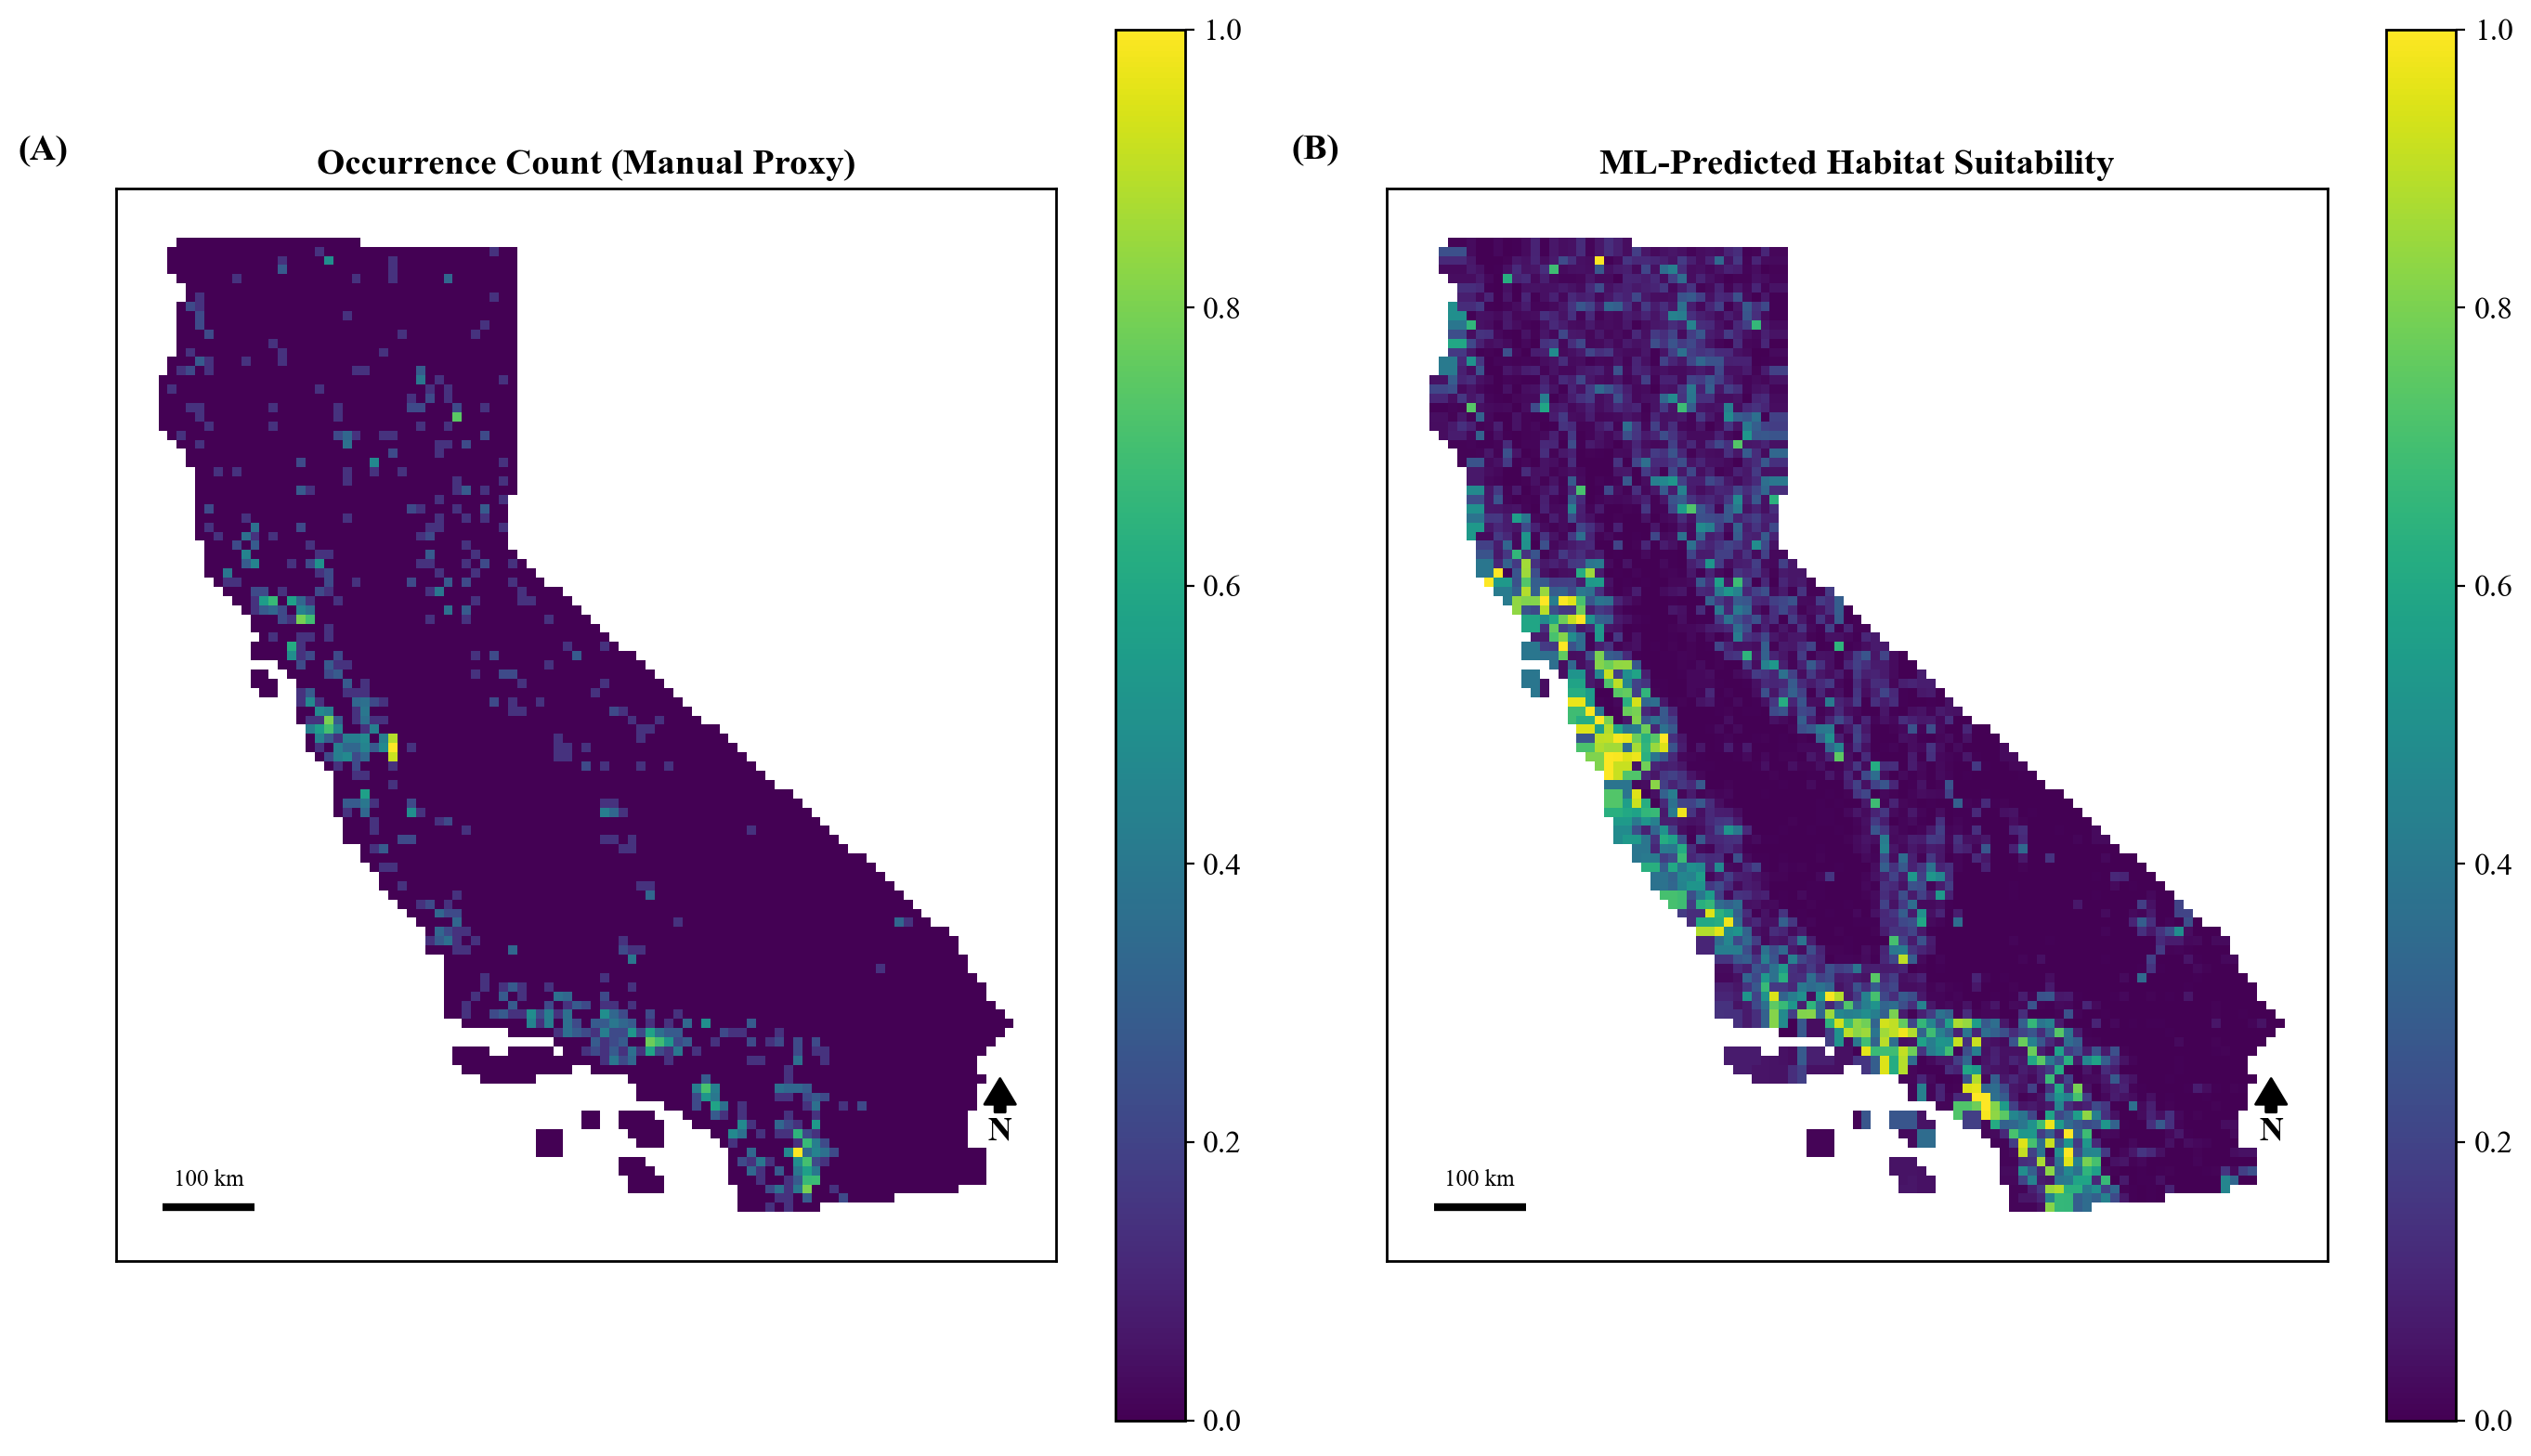

Saved: fig1_v1_vs_v2.png
Suggested caption: Figure 1. Manual occurrence-count proxy (A) vs. Random Forest-predicted habitat suitability (B).



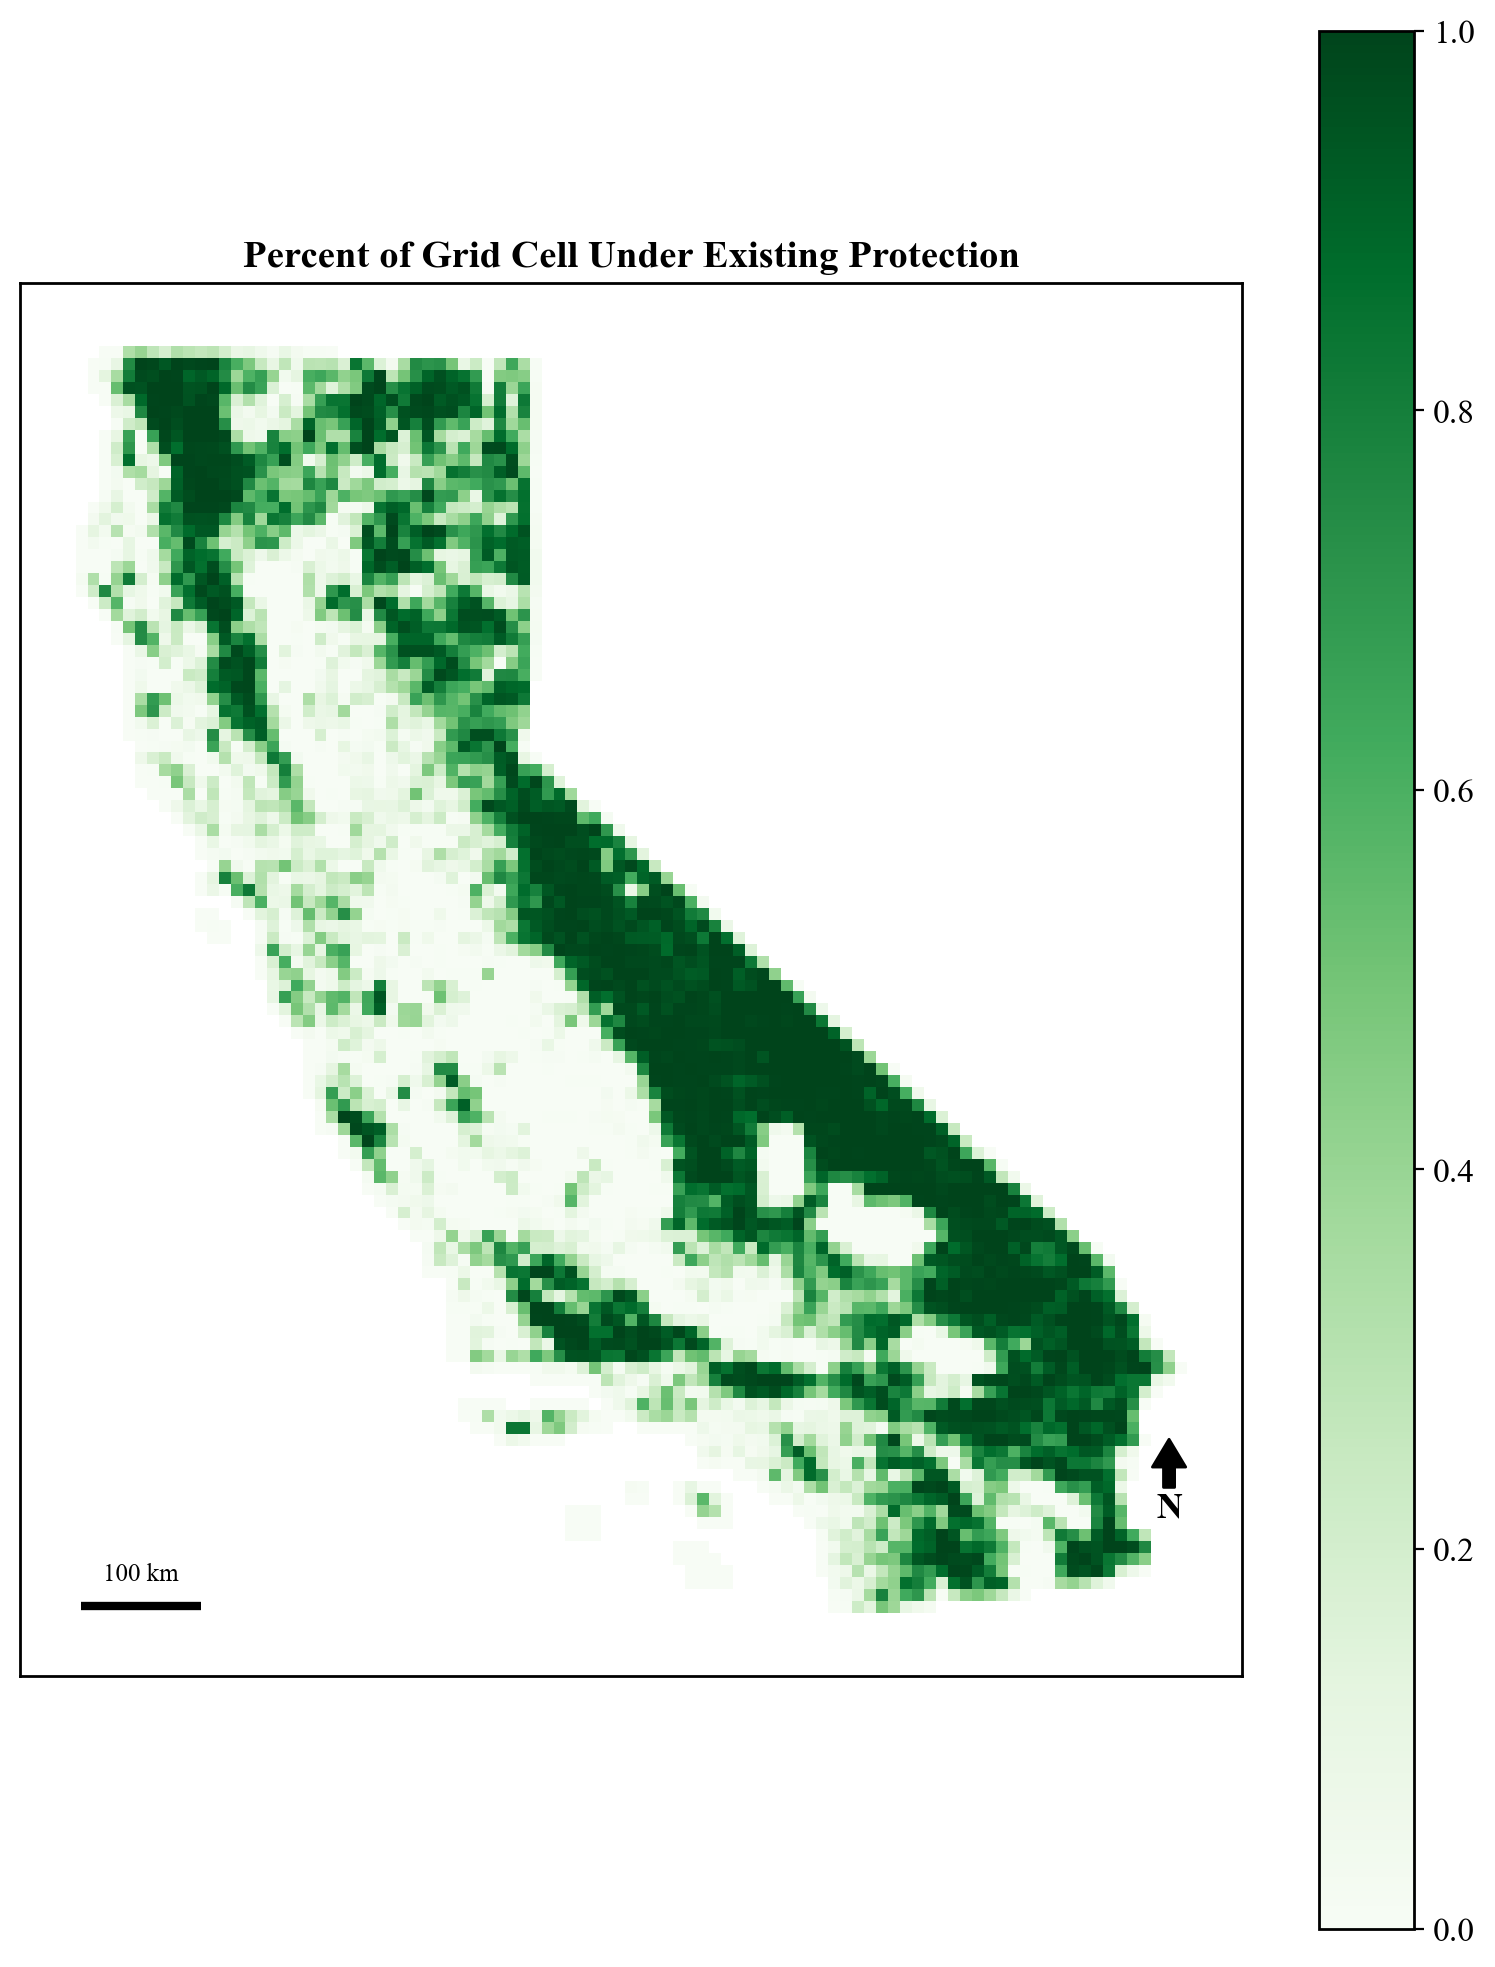

Saved: fig2_protection_status.png
Suggested caption: Figure 2. Percent of each grid cell under existing protection (CPAD Holdings).



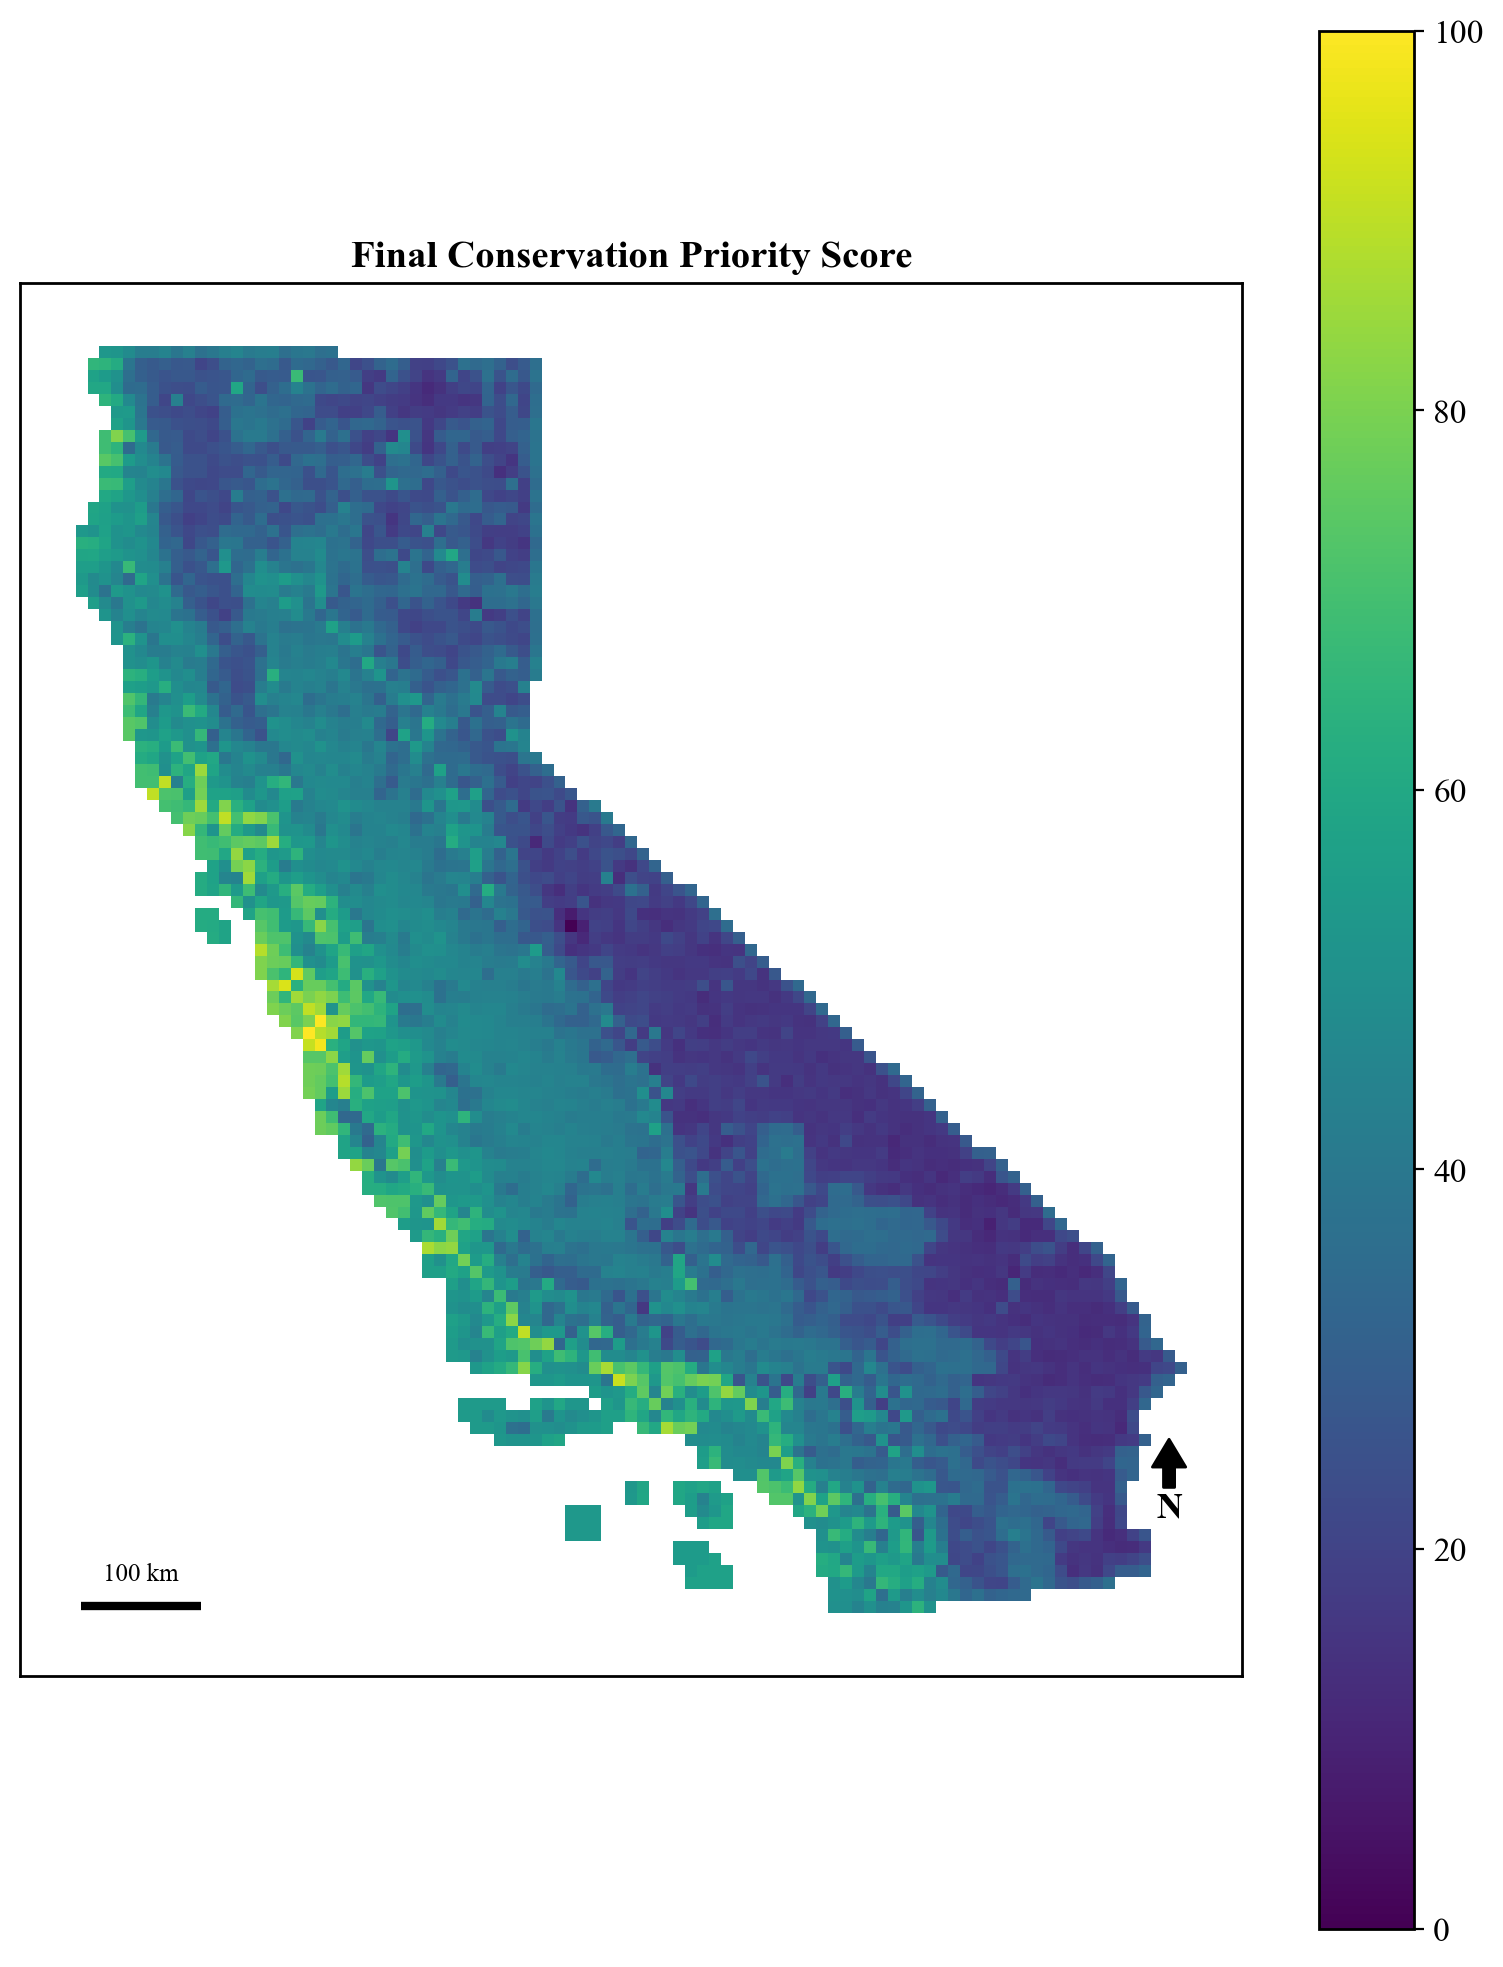

Saved: fig4_priority_v4.png
Suggested caption: Figure 4. Final connectivity-aware conservation priority score (0-100) by grid cell.



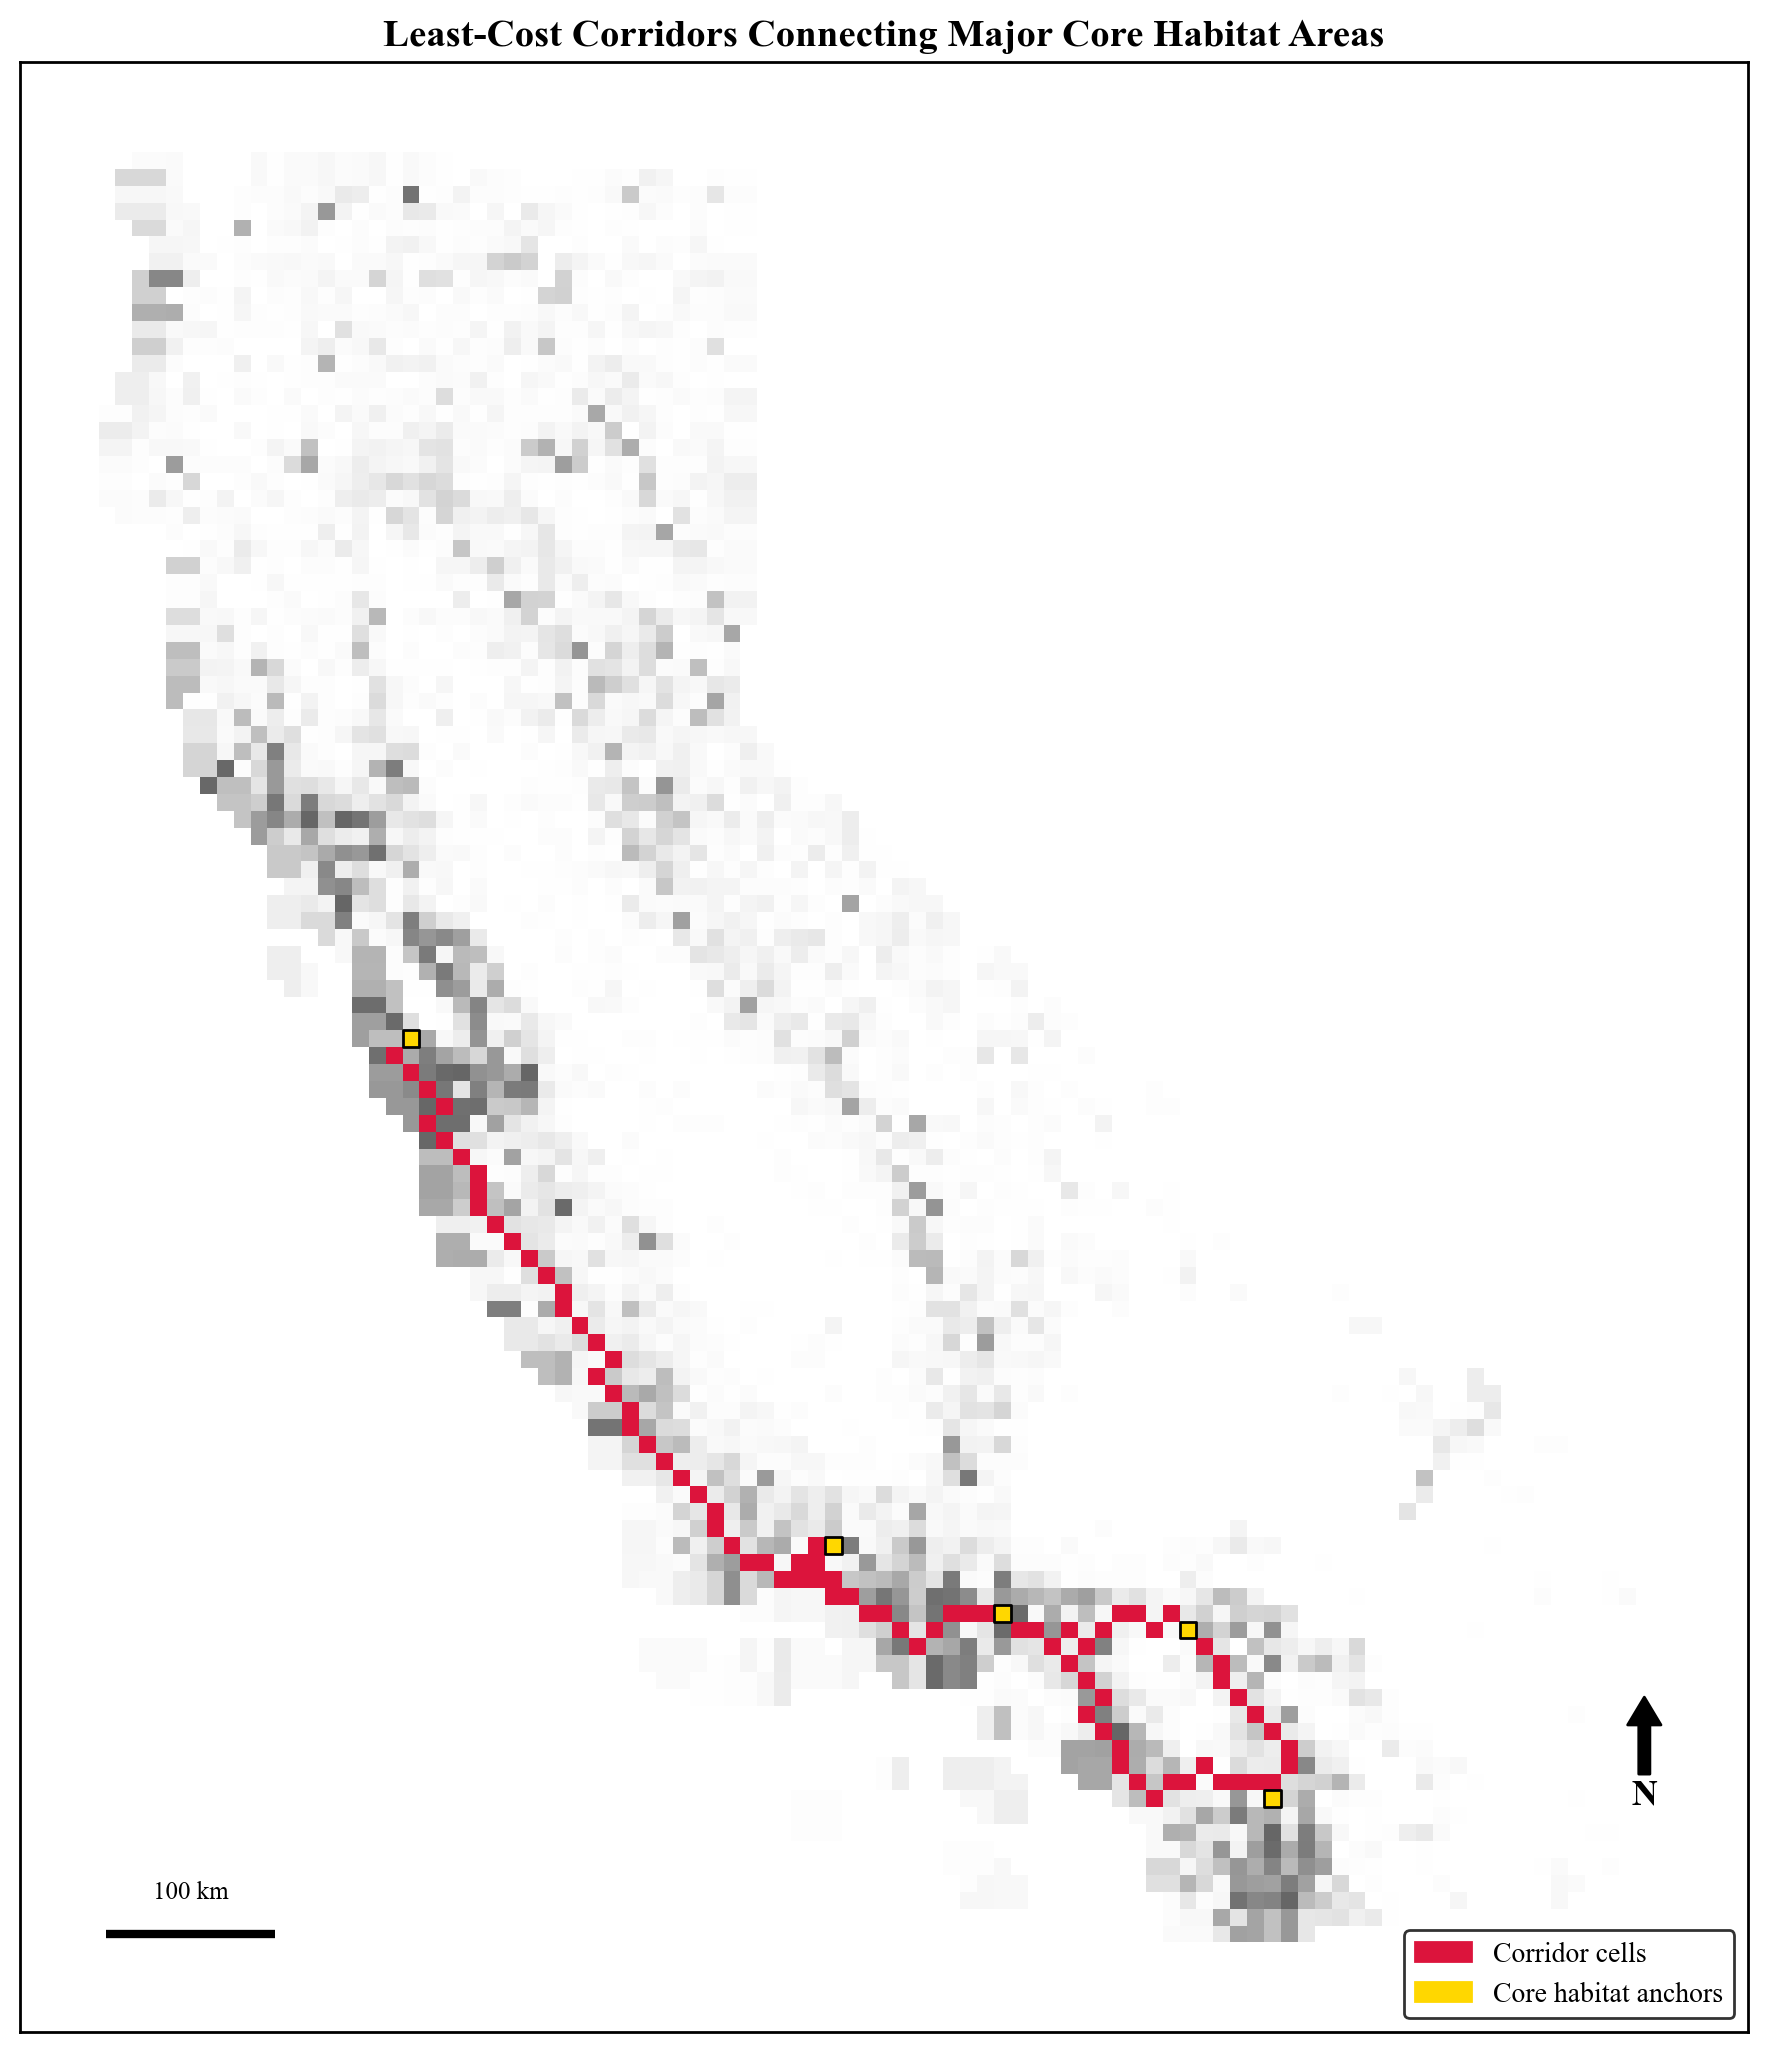

Saved: fig5_corridors.png
Suggested caption: Figure 5. Least-cost corridors (red) connecting the five largest core habitat clusters (gold markers), overlaid on predicted habitat suitability (greyscale).



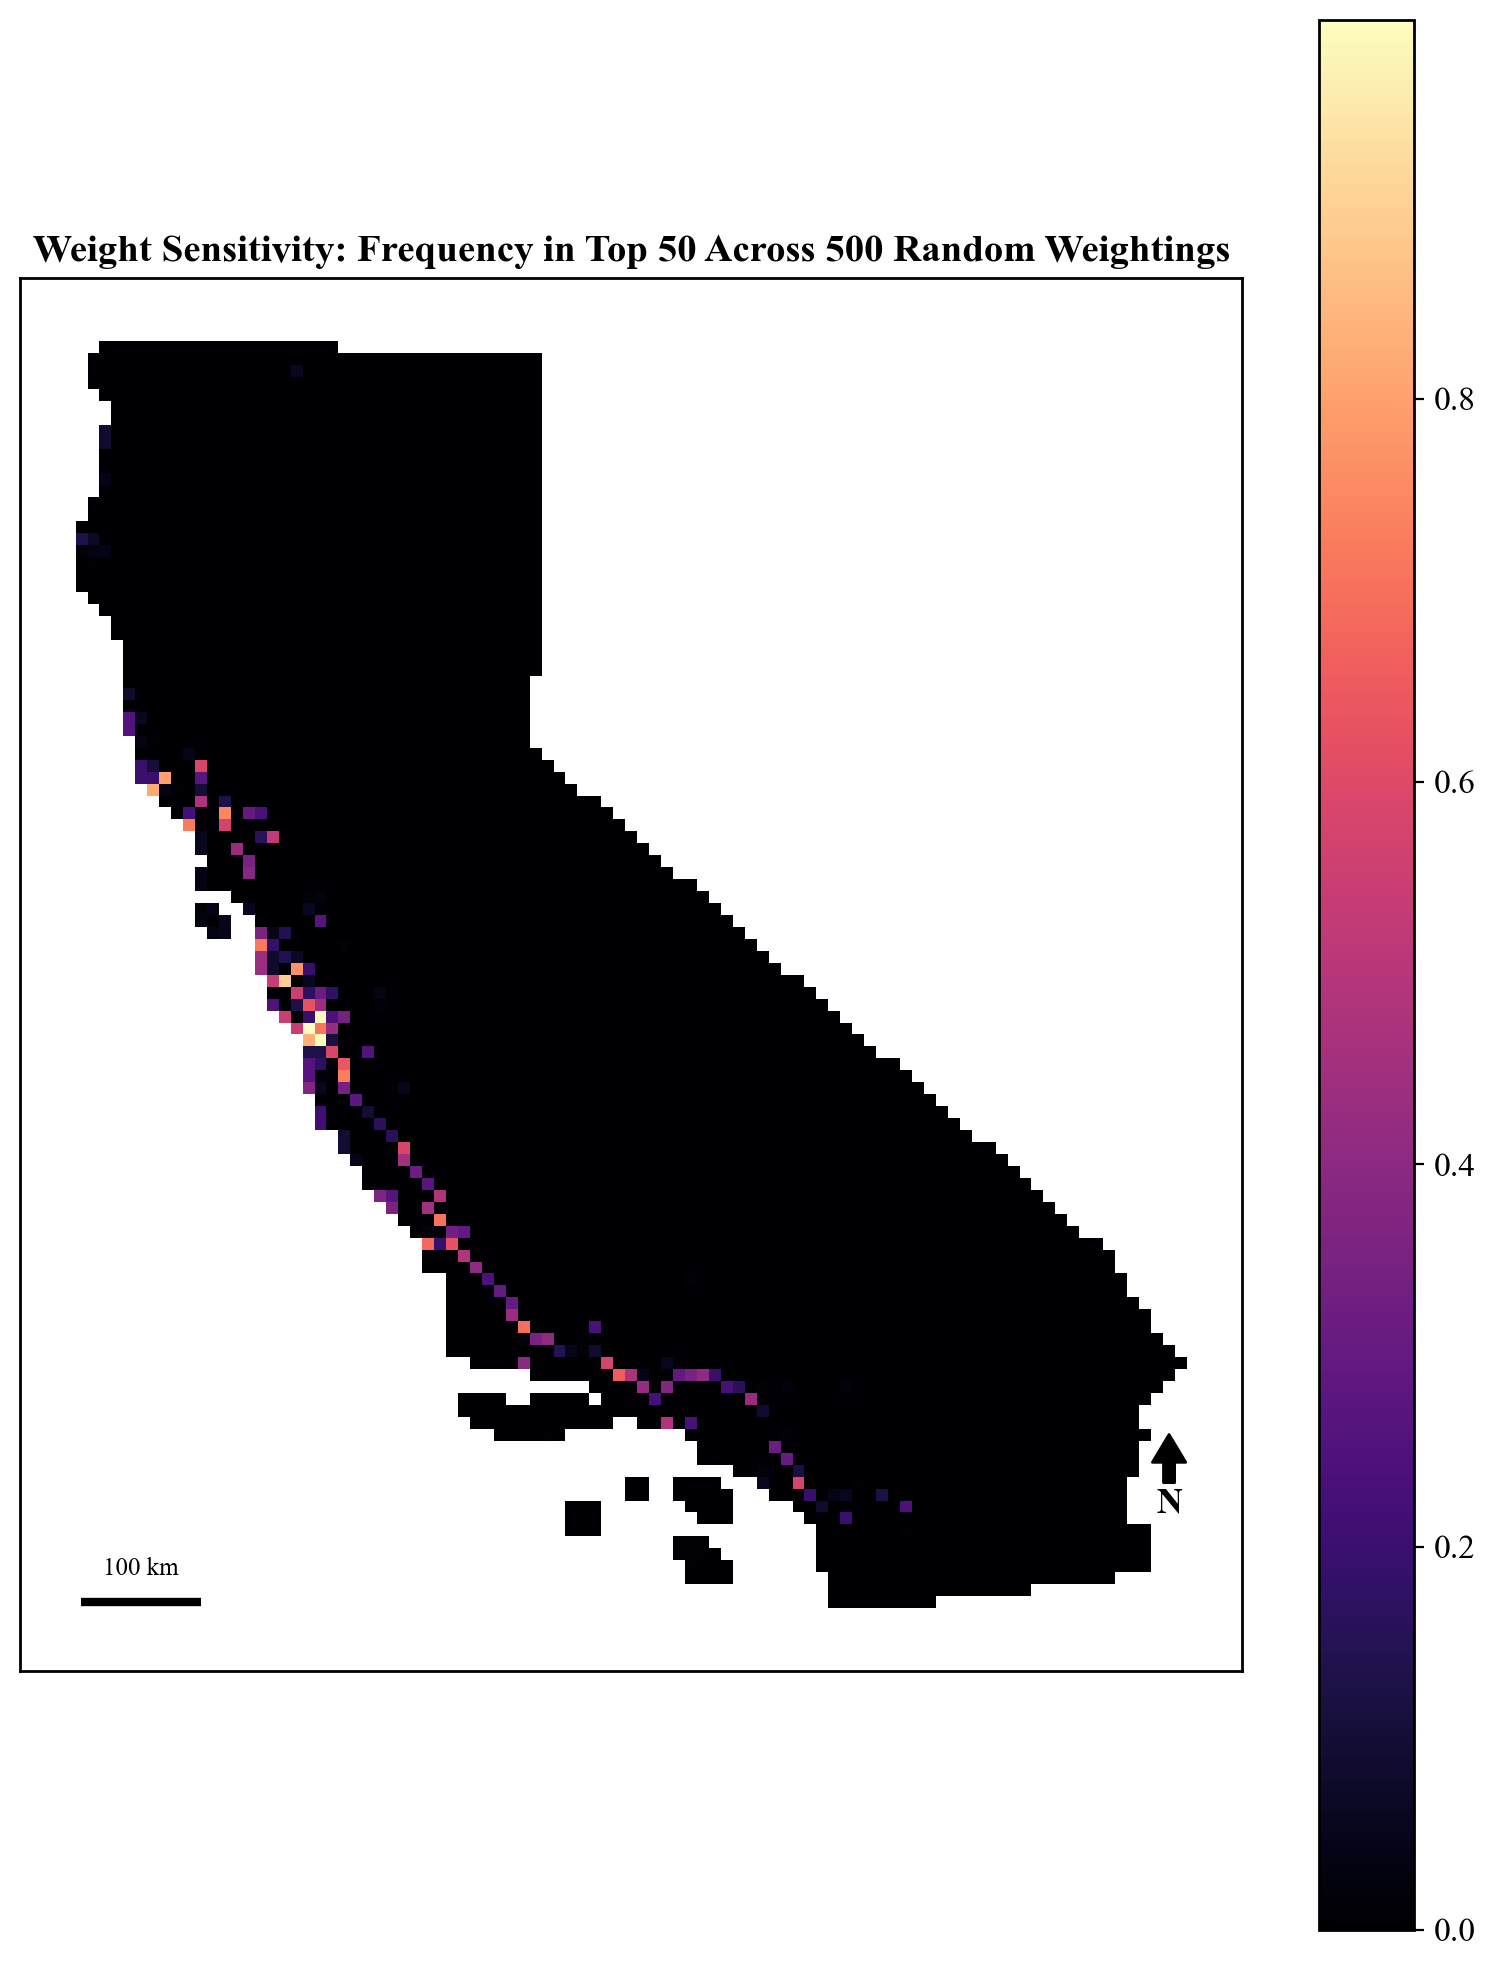

Saved: fig6_sensitivity.png
Suggested caption: Figure 6. Per-cell sensitivity frequency: proportion of 500 randomly weighted simulations in which each cell ranked in the top 50 priority cells.

All final figures saved to your working directory.


In [117]:
# ============================================================
# FINAL FIGURES — journal-style versions of all key maps
# Paste this as the LAST cell(s) in your notebook, after everything
# above has been run top to bottom at least once (so grid, grid_3310,
# anchors, corridors, etc. all exist in memory).
# ============================================================

import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

# ---- 1. Global journal-style settings ----
plt.rcParams.update({
    "font.family": "serif",
    "font.serif": ["Times New Roman", "DejaVu Serif"],
    "font.size": 12,
    "axes.titlesize": 14,
    "axes.titleweight": "bold",
    "axes.labelsize": 11,
    "legend.fontsize": 10,
    "legend.frameon": True,
    "legend.edgecolor": "black",
    "figure.dpi": 200,
    "savefig.dpi": 300,
    "axes.edgecolor": "black",
    "axes.linewidth": 1.0,
})

CMAP_SUITABILITY = "viridis"
CMAP_PROTECTION = "Greens"
CMAP_SENSITIVITY = "magma"


def add_north_arrow(ax, x=0.94, y=0.12, size=0.05):
    ax.annotate(
        "N", xy=(x, y + size), xytext=(x, y),
        xycoords="axes fraction", textcoords="axes fraction",
        ha="center", va="center", fontsize=13, fontweight="bold",
        arrowprops=dict(facecolor="black", width=4, headwidth=12, headlength=10),
    )


def add_scale_bar(ax, length_km=100, location=(0.05, 0.05)):
    x0, y0 = location
    xlim = ax.get_xlim()
    map_width_m = xlim[1] - xlim[0]
    bar_length_m = length_km * 1000
    x_start = xlim[0] + x0 * map_width_m
    x_end = x_start + bar_length_m
    ylim = ax.get_ylim()
    y_pos = ylim[0] + y0 * (ylim[1] - ylim[0])
    ax.plot([x_start, x_end], [y_pos, y_pos], color="black", linewidth=3, solid_capstyle="butt")
    ax.text((x_start + x_end) / 2, y_pos + 0.015 * (ylim[1] - ylim[0]),
            f"{length_km} km", ha="center", va="bottom", fontsize=9)


def add_panel_label(ax, label, x=-0.05, y=1.05):
    ax.text(x, y, f"({label})", transform=ax.transAxes,
            fontsize=14, fontweight="bold", va="top", ha="right")


def clean_axes(ax):
    ax.set_xticks([])
    ax.set_yticks([])
    for spine in ax.spines.values():
        spine.set_visible(True)


def finalize_and_save(fig, filename, caption):
    plt.tight_layout()
    fig.savefig(f"{filename}.png", bbox_inches="tight")
    plt.show()
    print(f"Saved: {filename}.png")
    print(f"Suggested caption: {caption}\n")


# ============================================================
# Figure 1 — Manual occurrence proxy vs. ML-predicted suitability
# ============================================================
fig, axes = plt.subplots(1, 2, figsize=(14, 8))

grid.plot(column="log_occurrence_count_scaled", cmap=CMAP_SUITABILITY, legend=True, ax=axes[0], edgecolor="none")
axes[0].set_title("Occurrence Count (Manual Proxy)")
clean_axes(axes[0])
add_panel_label(axes[0], "A")
add_north_arrow(axes[0])
add_scale_bar(axes[0], length_km=100)

grid.plot(column="ml_habitat_suitability", cmap=CMAP_SUITABILITY, legend=True, ax=axes[1], edgecolor="none")
axes[1].set_title("ML-Predicted Habitat Suitability")
clean_axes(axes[1])
add_panel_label(axes[1], "B")
add_north_arrow(axes[1])
add_scale_bar(axes[1], length_km=100)

finalize_and_save(
    fig, "fig1_v1_vs_v2",
    "Figure 1. Manual occurrence-count proxy (A) vs. Random Forest-predicted habitat suitability (B)."
)

# ============================================================
# Figure 2 — Existing protection status
# ============================================================
fig, ax = plt.subplots(figsize=(8, 10))
grid.plot(column="pct_protected", cmap=CMAP_PROTECTION, legend=True, ax=ax, edgecolor="none")
ax.set_title("Percent of Grid Cell Under Existing Protection")
clean_axes(ax)
add_north_arrow(ax)
add_scale_bar(ax, length_km=100)

finalize_and_save(
    fig, "fig2_protection_status",
    "Figure 2. Percent of each grid cell under existing protection (CPAD Holdings)."
)

# ============================================================
# Figure 4 — Final connectivity-aware priority score (v4)
# ============================================================
fig, ax = plt.subplots(figsize=(8, 10))
grid.plot(column="priority_score_v4_100", cmap=CMAP_SUITABILITY, legend=True, ax=ax, edgecolor="none")
ax.set_title("Final Conservation Priority Score")
clean_axes(ax)
add_north_arrow(ax)
add_scale_bar(ax, length_km=100)

finalize_and_save(
    fig, "fig4_priority_v4",
    "Figure 4. Final connectivity-aware conservation priority score (0-100) by grid cell."
)

# ============================================================
# Figure 5 — Least-cost corridors connecting core habitat areas
# ============================================================
fig, ax = plt.subplots(figsize=(9, 11))
grid_3310.plot(column="ml_habitat_suitability", cmap="Greys", ax=ax, edgecolor="none", alpha=0.6)
grid_3310[grid_3310["in_corridor"]].plot(ax=ax, color="crimson", linewidth=0, label="Corridor cells")
grid_3310[grid_3310["is_anchor"]].plot(ax=ax, color="gold", edgecolor="black", linewidth=1, markersize=80, label="Core habitat anchors")
ax.set_title("Least-Cost Corridors Connecting Major Core Habitat Areas")
clean_axes(ax)
add_north_arrow(ax)
add_scale_bar(ax, length_km=100)

corridor_patch = mpatches.Patch(color="crimson", label="Corridor cells")
anchor_patch = mpatches.Patch(color="gold", label="Core habitat anchors")
ax.legend(handles=[corridor_patch, anchor_patch], loc="lower right")

finalize_and_save(
    fig, "fig5_corridors",
    "Figure 5. Least-cost corridors (red) connecting the five largest core habitat clusters "
    "(gold markers), overlaid on predicted habitat suitability (greyscale)."
)

# ============================================================
# Figure 6 — Weight sensitivity frequency
# ============================================================
fig, ax = plt.subplots(figsize=(8, 10))
grid.plot(column="sensitivity_frequency", cmap=CMAP_SENSITIVITY, legend=True, ax=ax, edgecolor="none")
ax.set_title("Weight Sensitivity: Frequency in Top 50 Across 500 Random Weightings")
clean_axes(ax)
add_north_arrow(ax)
add_scale_bar(ax, length_km=100)

finalize_and_save(
    fig, "fig6_sensitivity",
    "Figure 6. Per-cell sensitivity frequency: proportion of 500 randomly weighted simulations "
    "in which each cell ranked in the top 50 priority cells."
)

print("All final figures saved to your working directory.")